# Regenerate Figure 2 — raw signal traces

Extracts 10 representative reads per end-reason class from a bulk FAST5.

**Read model:** each real read spans many consecutive `IntermediateData/Reads` rows sharing a `read_id` (non-terminal rows are `partial`). End reason = **last** row of the group; extent = first row `read_start` .. last row `read_start+read_length`. Reads are filtered to a per-class length window **and** body median ≥ 40 pA (conducting strand, not a dead/zero segment), then 10 are sampled evenly by `read_id`.

Reference notebook: `Y:\\kdiya\\1_sandbox_end_reason\\signal_visual\\testrun.ipynb`.

In [3]:
import h5py
import numpy as np
import collections
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import vbz_h5py_plugin # needed for VBZ-compressed FAST5 signal
import pysam # for BAM
import pod5 as p5 # for POD5 verification

F5 = r"/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_data/Single_Molecule_Seqeuncing_Cutting_Res_E/Regular/20250519_1041_MN48328_AYJ384_c3faa658/rdlu0053_20250519_1046_AYJ384_MN48328_sequencing_run_Regular_c3faa658_2e5a2515.fast5"
BAM = r"/nfs/turbo/umms-atheylab/hrli/Code/dorado-run/Output/20250519_1041_MN48328_AYJ384_c3faa658_sup_v5.2.0_trim1_10.bam"
POD5_PATH = r"/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_data/Single_Molecule_Seqeuncing_Cutting_Res_E/Regular/20250519_1041_MN48328_AYJ384_c3faa658/pod5"

FS = 5000.0
MIN_Q = 10
N = 10
PRE = 2000
POST = 2000

# Keep these categories if you only want these end reasons.
# Set END_REASONS = None if you want all end reasons.
END_REASONS = {
    "signal_positive",
    "signal_negative",
    "unblock_mux_change",
    "mux_change",
}


In [4]:
def read_qscore_from_bam_record(aln):
    """
    Return read-level Q score from a BAM alignment.

    Priority:
    1. ONT/Dorado-style qs tag, if present
    2. Mean base quality from query_qualities
    """
    if aln.has_tag("qs"):
        return float(aln.get_tag("qs"))

    if aln.query_qualities is not None and len(aln.query_qualities) > 0:
        return float(np.mean(aln.query_qualities))

    return None

def get_high_q_read_ids_from_bam(bam_path, min_q=10):
    high_q_read_ids = set()
    q_by_read = {}

    with pysam.AlignmentFile(bam_path, "rb", check_sq=False) as bam:
        for aln in bam:
            if aln.is_secondary or aln.is_supplementary:
                continue

            read_id = aln.query_name
            q = read_qscore_from_bam_record(aln)

            if q is None:
                continue

            q_by_read[read_id] = q

            if q >= min_q:
                high_q_read_ids.add(read_id)

    print("BAM reads with Q score found:", len(q_by_read))
    print(f"BAM reads with Q >= {min_q}:", len(high_q_read_ids))

    return high_q_read_ids, q_by_read

high_q_read_ids, q_by_read = get_high_q_read_ids_from_bam(BAM, MIN_Q)

BAM reads with Q score found: 381753
BAM reads with Q >= 10: 362088


## 1. Group rows into reads; record end reason, extent, conducting level

In [8]:
# 1. Group rows into reads; record end reason, extent, conducting level
#    Now filtering by BAM qs tag instead of WIN length filters.

h = h5py.File(F5, "r")  # read-only

# Find a channel that actually has a Reads table
example_reads = None
for ch in h["IntermediateData"]:
    if "Reads" in h["IntermediateData"][ch]:
        example_reads = h["IntermediateData"][ch]["Reads"]
        break

if example_reads is None:
    raise ValueError("No IntermediateData/<channel>/Reads dataset found.")

# Decode the HDF5 enum for end_reason
enum = h5py.check_enum_dtype(
    example_reads.dtype.fields["end_reason"][0]
)

inv = {v: k for k, v in enum.items()}

pool = collections.defaultdict(list)

for ch in h["IntermediateData"]:
    g = h["IntermediateData"][ch]

    if "Reads" not in g:
        continue

    r = g["Reads"][:]

    rid = r["read_id"]
    er = r["end_reason"]
    rs = r["read_start"]
    rl = r["read_length"]

    # Keep median if available
    med = r["median"] if "median" in r.dtype.names else None

    n = len(rid)
    i = 0

    while i < n:
        j = i

        # Group consecutive rows with the same read_id
        while j + 1 < n and rid[j + 1] == rid[i]:
            j += 1

        # Convert read_id to string
        read_id = rid[i].decode() if isinstance(rid[i], bytes) else str(rid[i])

        # End reason comes from the LAST row in this read group
        name = inv.get(int(er[j]))

        # Filter by BAM qs >= MIN_Q
        if read_id in high_q_read_ids:

            # Optional: keep only the end reasons you care about
            if END_REASONS is None or name in END_REASONS:

                # Read extent across the grouped rows
                start = int(rs[i])
                end = int(rs[j] + rl[j])

                body_median = (
                    float(np.median(med[i:j + 1]))
                    if med is not None
                    else np.nan
                )

                pool[name].append(
                    {
                        "channel": ch,
                        "read_id": read_id,
                        "start": start,
                        "end": end,
                        "length": end - start,
                        "duration_s": (end - start) / FS,
                        "n_rows": j - i + 1,
                        "body_median": body_median,
                        "bam_qscore": q_by_read.get(read_id),
                        "end_reason": name,
                    }
                )

        i = j + 1

print({k: len(v) for k, v in pool.items()})

{'signal_positive': 350591, 'unblock_mux_change': 8415, 'mux_change': 251, 'signal_negative': 743}


unblock_mux_change available: 8415 picked: 40
read_id: b83b7dfa-94f0-422e-b175-da5ca87c8e86 | qs: 23.134443283081055 | start: 1188413 | end: 1215347 | duration_s: 5.39 | end_reason: unblock_mux_change


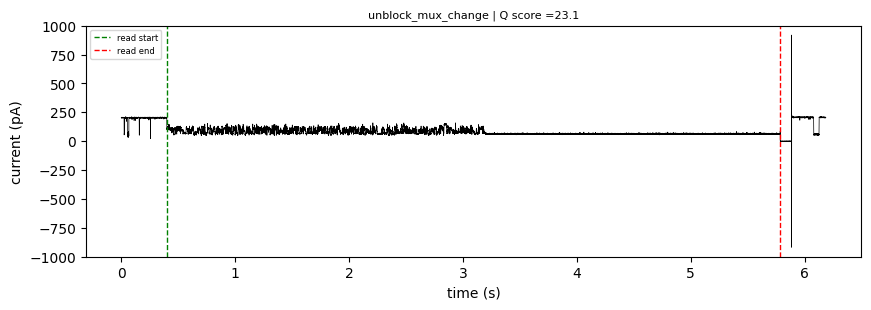

read_id: f37eb3df-40e9-4661-bc2d-aeb853e170b9 | qs: 19.226362228393555 | start: 12347592 | end: 12441464 | duration_s: 18.77 | end_reason: unblock_mux_change


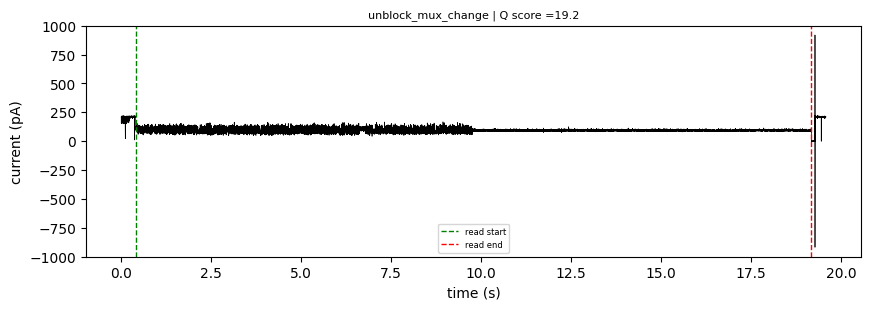

read_id: 20d02042-26ba-4cdc-816a-008cfeddb08c | qs: 12.481382369995117 | start: 21959435 | end: 22006413 | duration_s: 9.4 | end_reason: unblock_mux_change


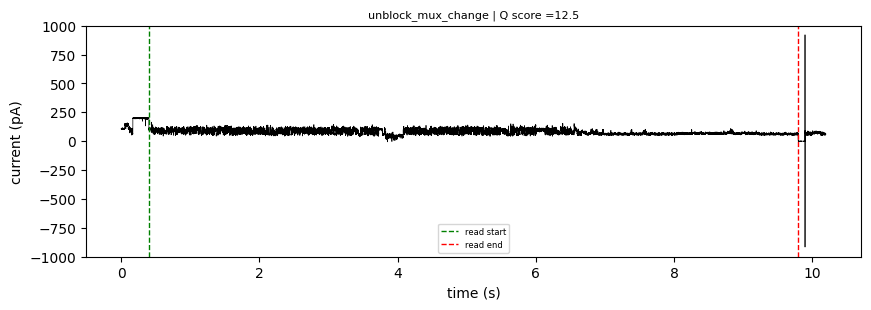

read_id: 0234b188-5b2a-443c-8f9b-0555dd8afe90 | qs: 22.713443756103516 | start: 32724327 | end: 32821665 | duration_s: 19.47 | end_reason: unblock_mux_change


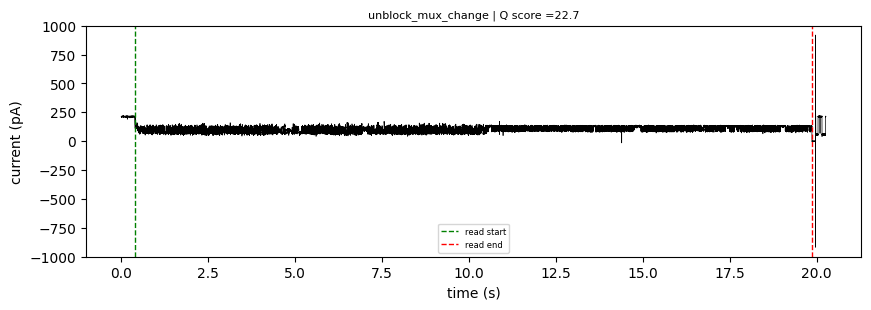

read_id: de1e16ae-e4f0-4f64-9a60-3058fbfcd774 | qs: 12.818300247192383 | start: 41288004 | end: 41421402 | duration_s: 26.68 | end_reason: unblock_mux_change


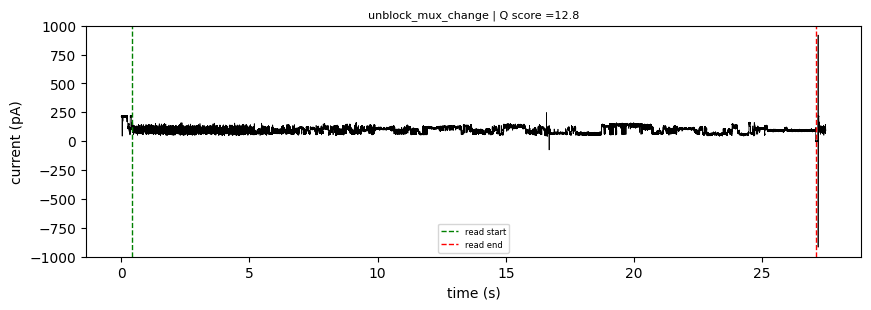

read_id: ff1bfc29-3b64-4cdb-bb66-005217dbb5bf | qs: 19.63479232788086 | start: 49002373 | end: 49087809 | duration_s: 17.09 | end_reason: unblock_mux_change


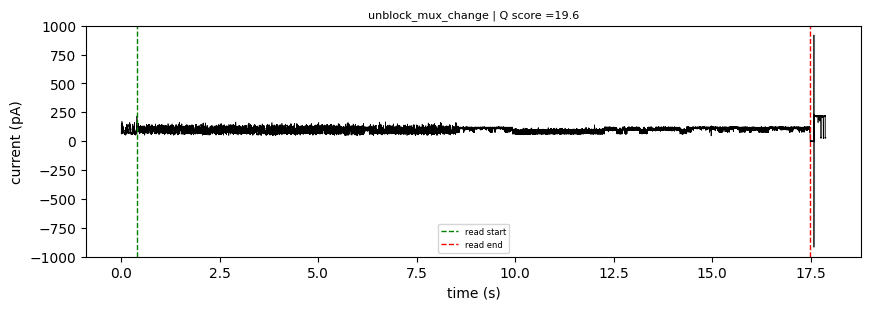

read_id: a3ae1832-83d0-426c-b4b7-2619d1355b0e | qs: 15.363545417785645 | start: 58944873 | end: 58965907 | duration_s: 4.21 | end_reason: unblock_mux_change


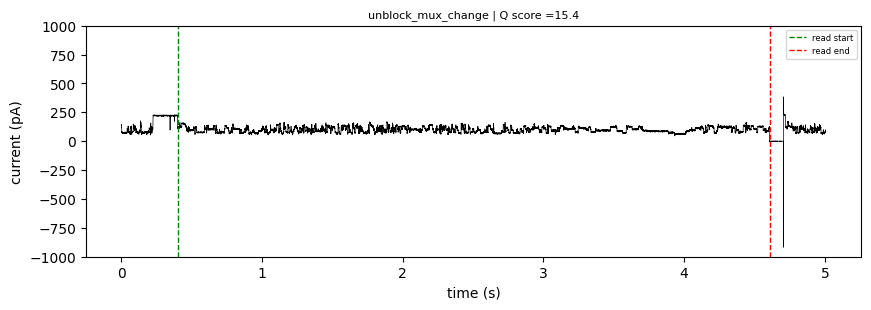

read_id: ad07aaec-9914-4a3c-be5b-653b1a4100a5 | qs: 21.06499481201172 | start: 68128204 | end: 68220930 | duration_s: 18.55 | end_reason: unblock_mux_change


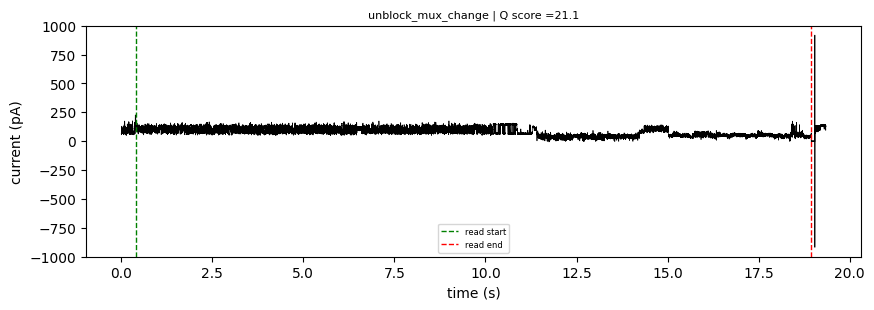

read_id: 43af9e73-5e10-462b-9c45-ee33113e62ff | qs: 12.63272762298584 | start: 75759590 | end: 75800098 | duration_s: 8.1 | end_reason: unblock_mux_change


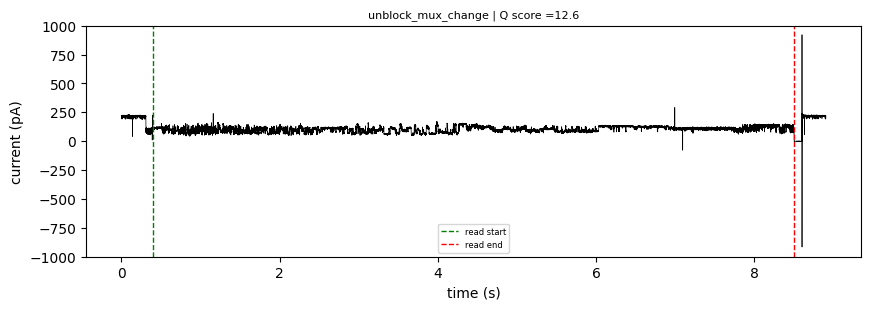

read_id: 178dca37-f608-41d8-b884-b5241008cd4f | qs: 16.380598068237305 | start: 84203979 | end: 84243333 | duration_s: 7.87 | end_reason: unblock_mux_change


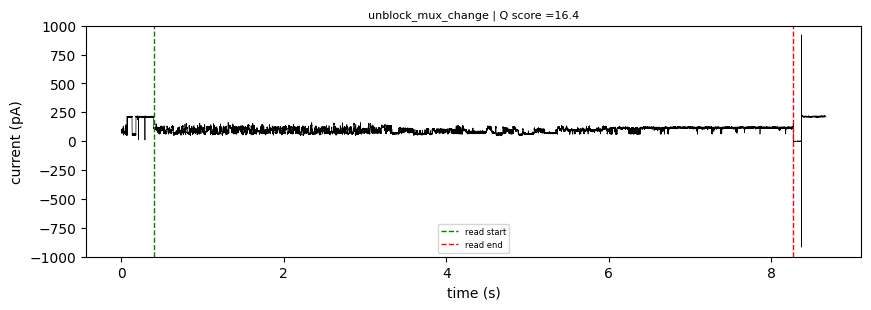

read_id: 2dd0c28a-e47a-4be9-a183-b9ec9893dc05 | qs: 14.108144760131836 | start: 93177238 | end: 93226074 | duration_s: 9.77 | end_reason: unblock_mux_change


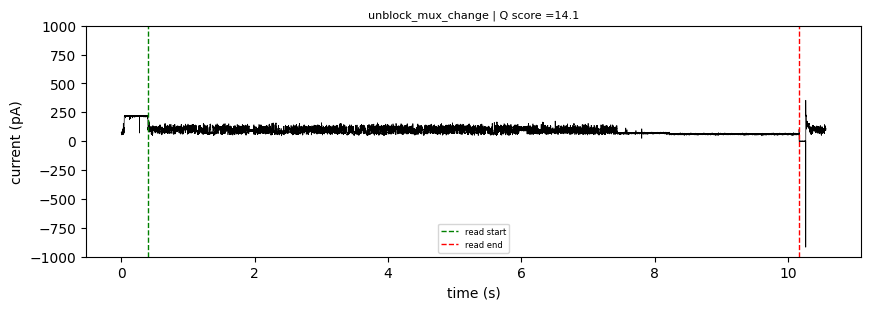

read_id: c124215f-8b5d-4b5d-9981-93dfa2d07af7 | qs: 13.538509368896484 | start: 100030385 | end: 100054730 | duration_s: 4.87 | end_reason: unblock_mux_change


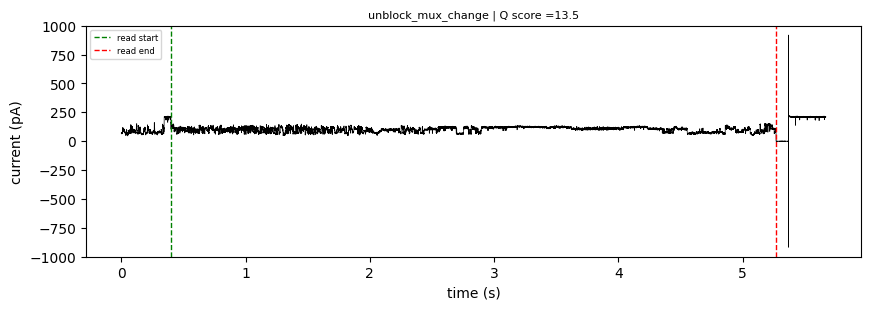

read_id: d95c54e5-22fe-4296-a43c-7ba39f6d4555 | qs: 16.606002807617188 | start: 108094058 | end: 108179610 | duration_s: 17.11 | end_reason: unblock_mux_change


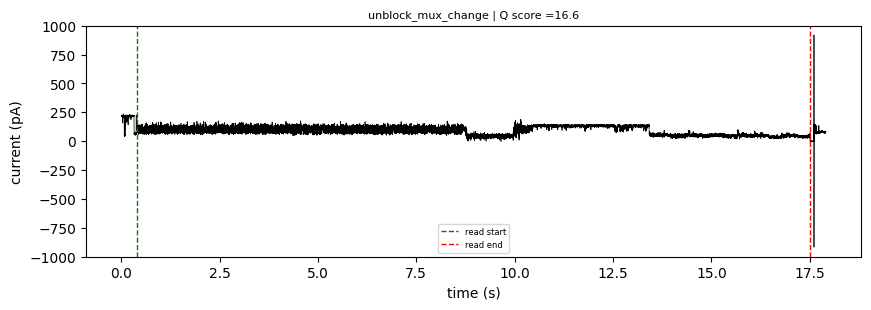

read_id: a4c352a2-bd2b-4559-b4df-957935e33756 | qs: 19.743637084960938 | start: 117609787 | end: 117656525 | duration_s: 9.35 | end_reason: unblock_mux_change


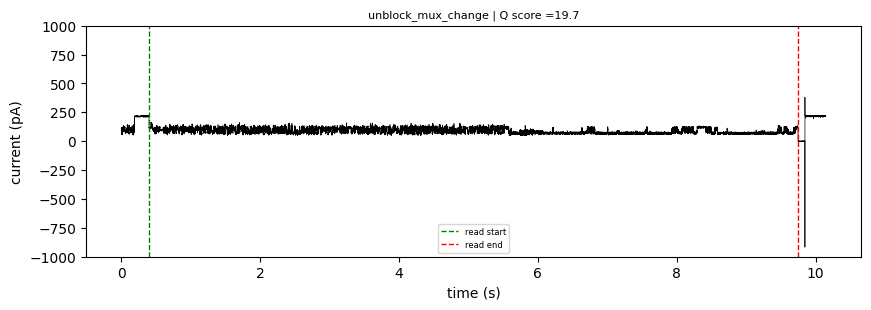

read_id: 526fb30d-02fa-48f1-b80b-08d0d528f190 | qs: 15.284228324890137 | start: 126628520 | end: 126667296 | duration_s: 7.76 | end_reason: unblock_mux_change


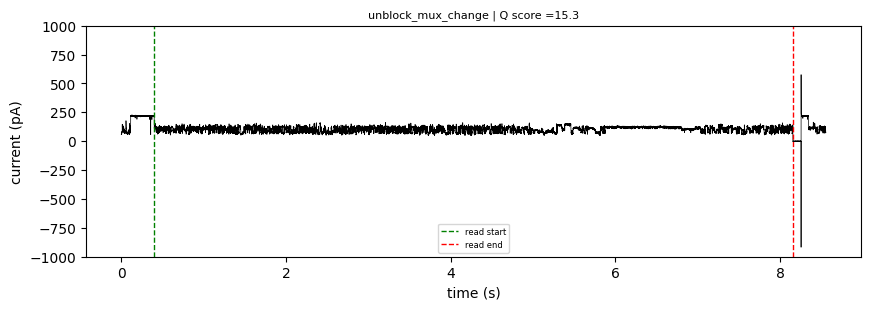

read_id: 0adf0a0e-384e-4c6b-bb03-117fce8578ab | qs: 11.224602699279785 | start: 133773889 | end: 133814361 | duration_s: 8.09 | end_reason: unblock_mux_change


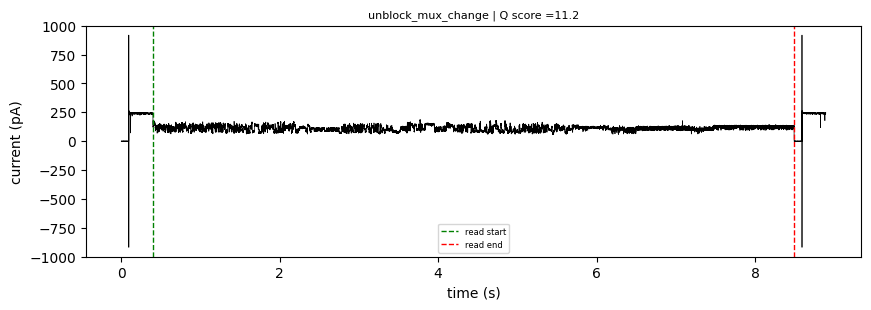

read_id: 99114db6-9ff3-4087-b083-efc861ebf119 | qs: 19.519912719726562 | start: 143408250 | end: 143439009 | duration_s: 6.15 | end_reason: unblock_mux_change


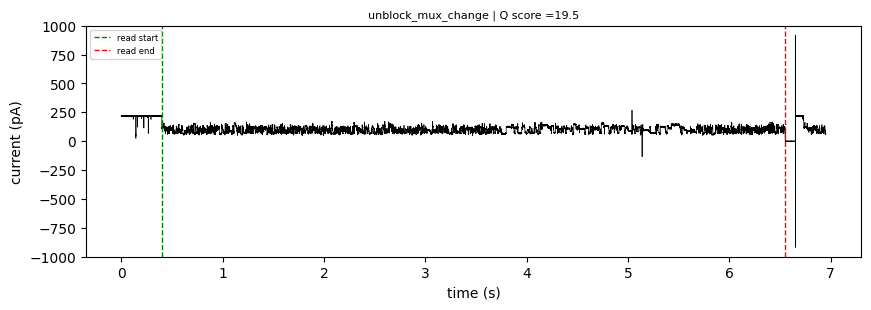

read_id: 9ce6e856-76de-472a-be26-14a8f0031207 | qs: 18.13274574279785 | start: 151703360 | end: 151741763 | duration_s: 7.68 | end_reason: unblock_mux_change


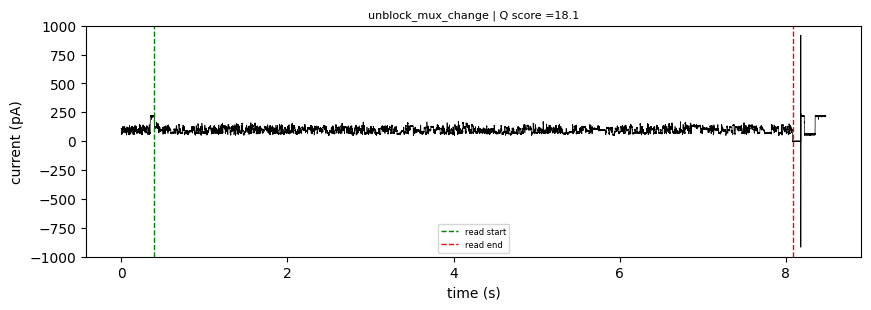

read_id: 267bfe28-4a71-4361-9f59-0a2d7dc9f11e | qs: 19.1093807220459 | start: 161550968 | end: 161677905 | duration_s: 25.39 | end_reason: unblock_mux_change


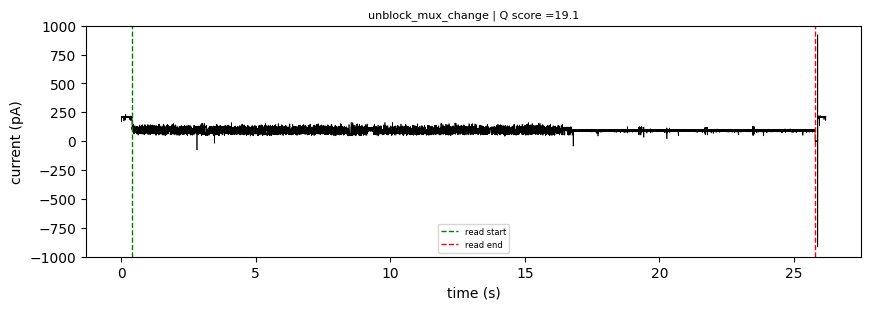

read_id: 844fdee9-2e77-4ee7-9349-181aa9380a88 | qs: 17.818397521972656 | start: 171588709 | end: 171639619 | duration_s: 10.18 | end_reason: unblock_mux_change


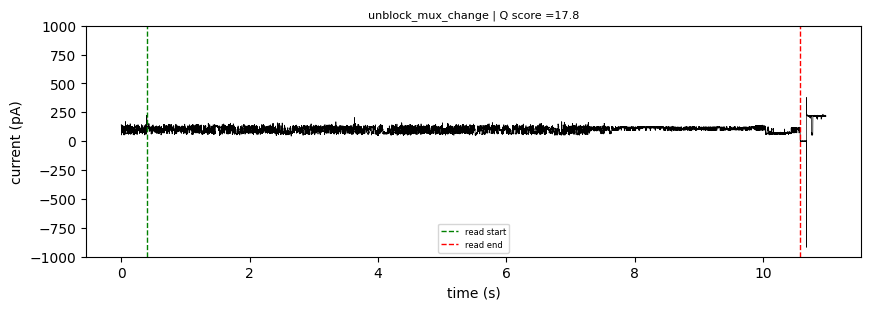

read_id: 25edebfe-23bf-4220-ba44-ea65b5de3a13 | qs: 16.420581817626953 | start: 181800131 | end: 181885206 | duration_s: 17.02 | end_reason: unblock_mux_change


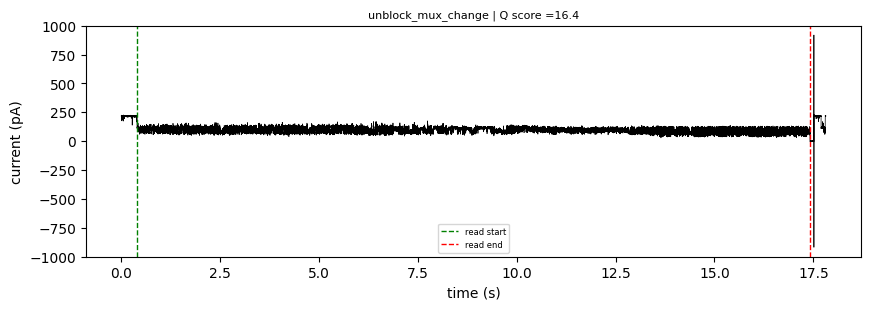

read_id: eca7f579-56a8-426d-821f-b51fc7e4c9ba | qs: 12.251585006713867 | start: 192222159 | end: 192263037 | duration_s: 8.18 | end_reason: unblock_mux_change


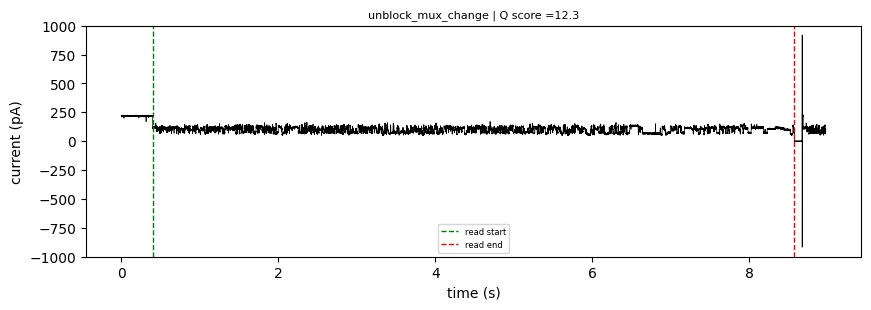

read_id: 79f4e71f-7ac8-4ac6-990d-4dd83cb9dfcf | qs: 15.92475700378418 | start: 203898381 | end: 203939810 | duration_s: 8.29 | end_reason: unblock_mux_change


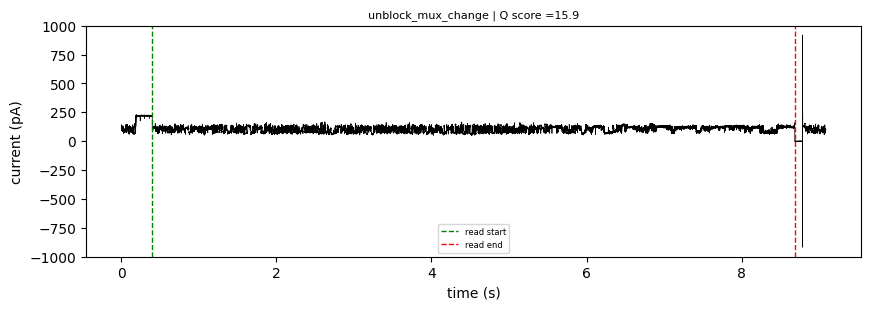

read_id: 192aa0d7-b048-4a67-a124-1785208272e9 | qs: 13.861178398132324 | start: 214866401 | end: 214912739 | duration_s: 9.27 | end_reason: unblock_mux_change


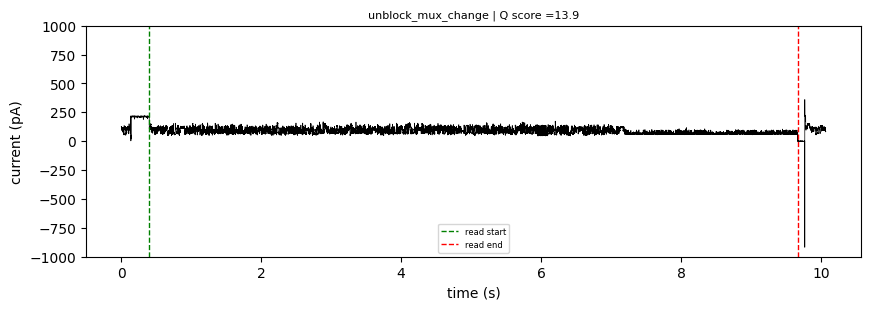

read_id: 98d88d7c-b249-4935-958f-575cf4872e4a | qs: 15.882969856262207 | start: 224128177 | end: 224152774 | duration_s: 4.92 | end_reason: unblock_mux_change


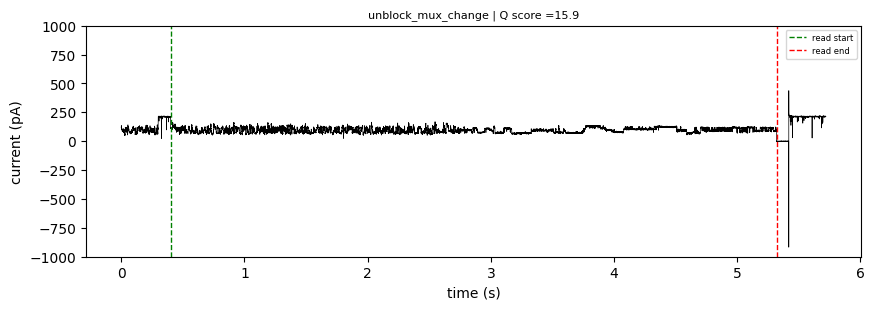

read_id: 1118930e-92a0-4b0a-a7b9-7ed529d9852f | qs: 14.339448928833008 | start: 234494804 | end: 234580254 | duration_s: 17.09 | end_reason: unblock_mux_change


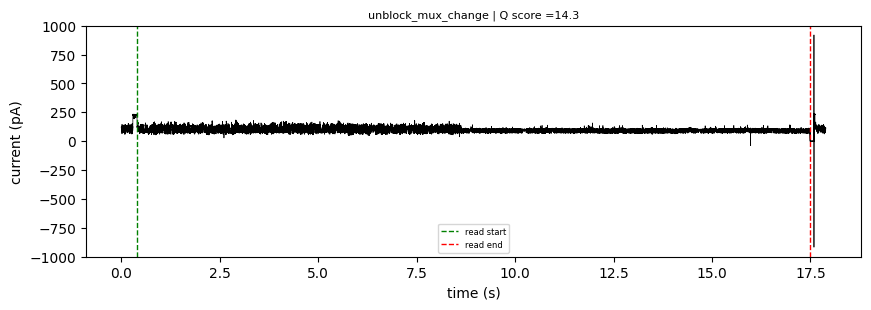

read_id: eb860f05-27aa-4b95-94ae-d8b8a7e63436 | qs: 17.52298927307129 | start: 244431983 | end: 244480786 | duration_s: 9.76 | end_reason: unblock_mux_change


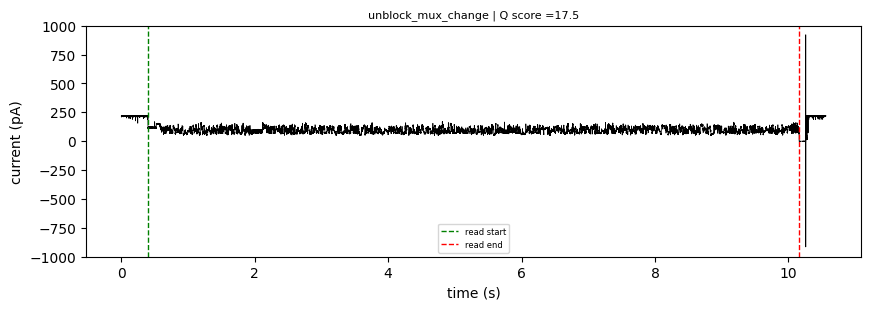

read_id: 55445943-0ace-4d76-90c7-61e887ffbbc6 | qs: 16.64495849609375 | start: 255842903 | end: 255875557 | duration_s: 6.53 | end_reason: unblock_mux_change


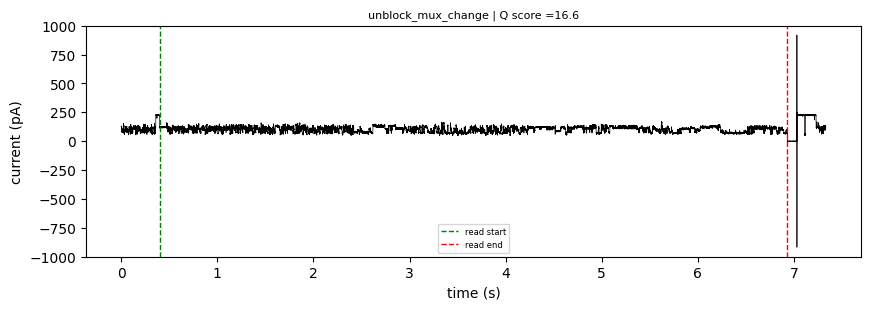

read_id: 216dab5c-aabf-4d9d-9f12-f52f5e1bd459 | qs: 15.248173713684082 | start: 265317761 | end: 265348451 | duration_s: 6.14 | end_reason: unblock_mux_change


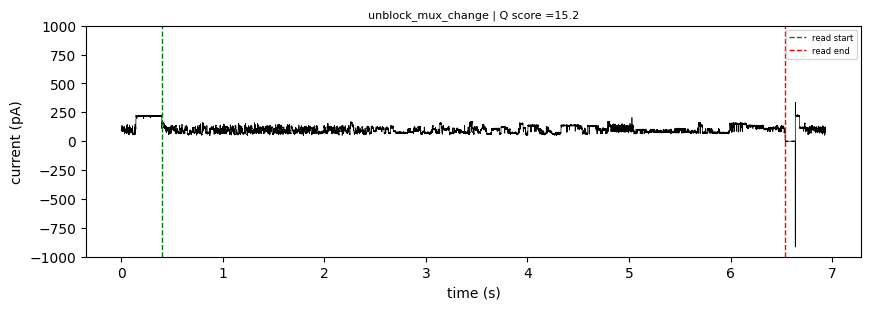

read_id: a8e6300f-02fc-4212-a4e1-d0e0c47c085c | qs: 15.760885238647461 | start: 276031683 | end: 276124633 | duration_s: 18.59 | end_reason: unblock_mux_change


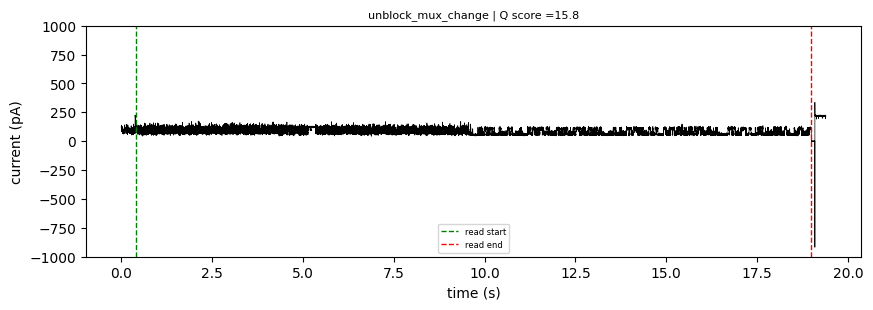

read_id: 661fdf9b-eae9-4505-b272-b416cca2cf28 | qs: 15.759866714477539 | start: 286885191 | end: 286990100 | duration_s: 20.98 | end_reason: unblock_mux_change


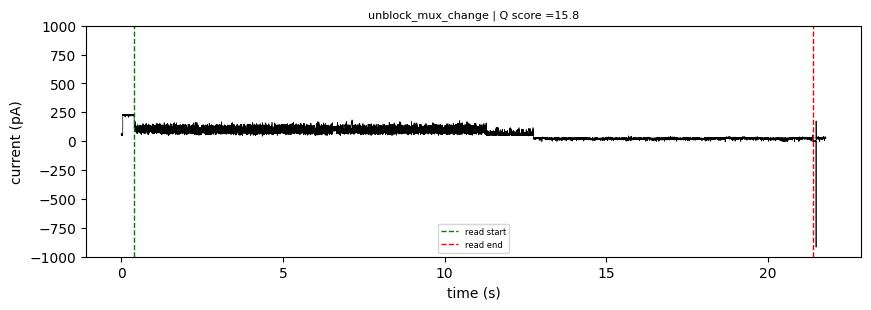

read_id: 6de71988-25c0-4ed7-a1aa-8b951d0c09ce | qs: 12.258184432983398 | start: 296700730 | end: 296795622 | duration_s: 18.98 | end_reason: unblock_mux_change


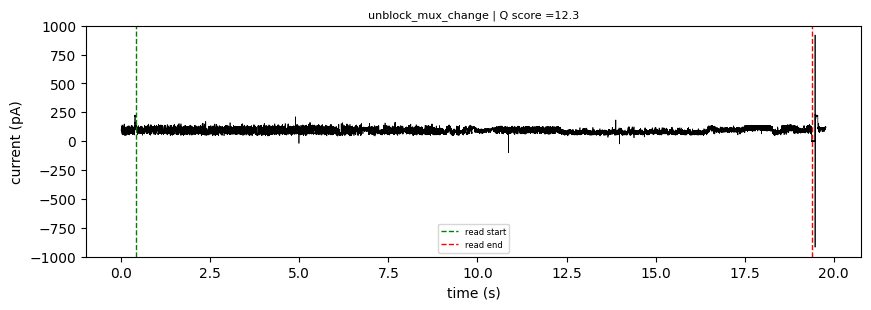

read_id: 8a025b97-693d-4c7d-a4df-7614cbe96871 | qs: 16.740127563476562 | start: 310406897 | end: 310497171 | duration_s: 18.05 | end_reason: unblock_mux_change


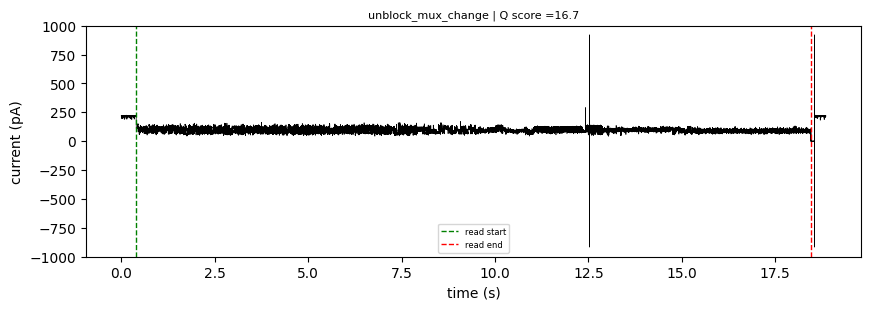

read_id: 3a5113c5-c2e9-48b6-b858-25d756bc69fc | qs: 16.740800857543945 | start: 322655097 | end: 322748001 | duration_s: 18.58 | end_reason: unblock_mux_change


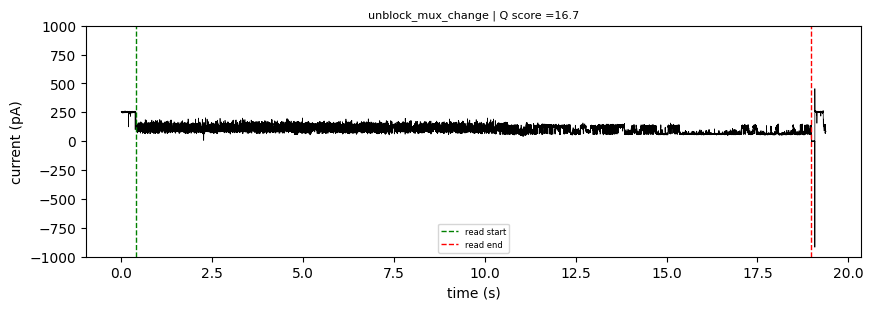

read_id: a1d65f72-8f4d-4611-a857-de44d8161dd2 | qs: 19.361997604370117 | start: 335800028 | end: 335885385 | duration_s: 17.07 | end_reason: unblock_mux_change


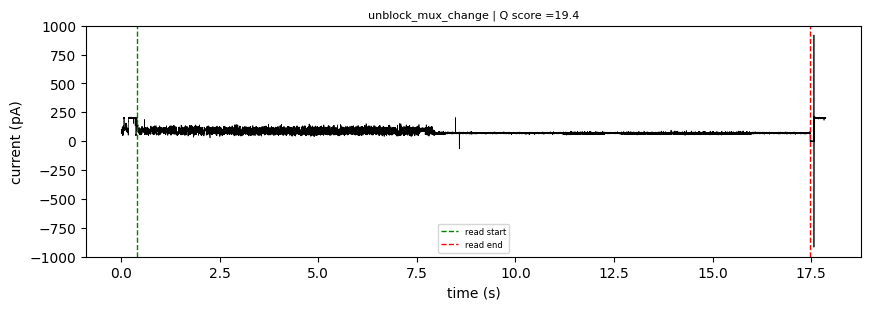

read_id: 999c55db-f1de-44b7-9bd4-a877c9e9c299 | qs: 19.328214645385742 | start: 350403973 | end: 350497096 | duration_s: 18.62 | end_reason: unblock_mux_change


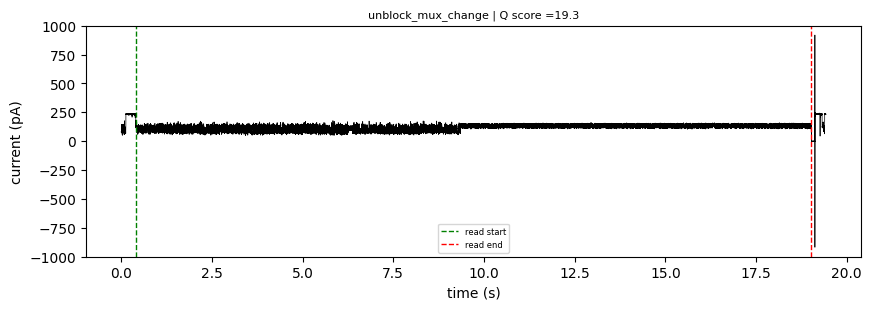

read_id: 67c91630-71be-4563-9795-40fec02c8615 | qs: 12.47811508178711 | start: 363136964 | end: 363184281 | duration_s: 9.46 | end_reason: unblock_mux_change


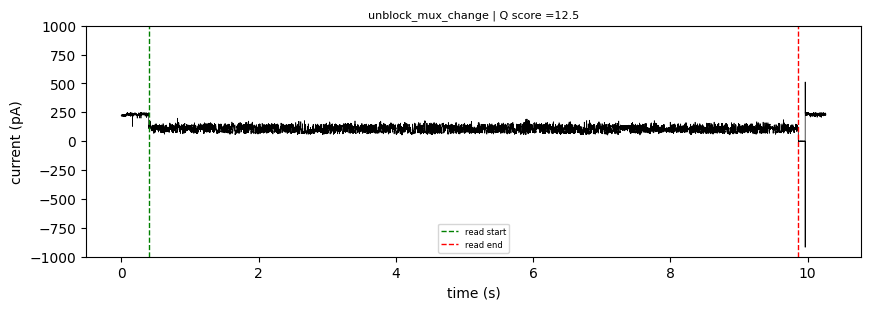

read_id: 6ecda268-d9cf-4d75-857e-debae9ff42c3 | qs: 14.013094902038574 | start: 380298336 | end: 380322587 | duration_s: 4.85 | end_reason: unblock_mux_change


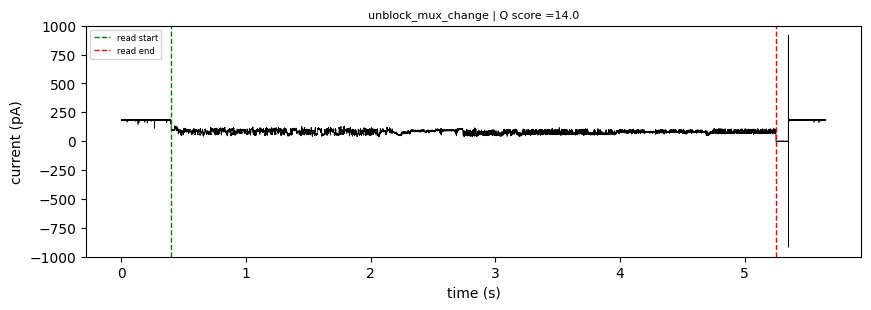

read_id: 3183084a-01b3-4581-93e1-a56e36cfe2d5 | qs: 11.61706829071045 | start: 396580686 | end: 396605792 | duration_s: 5.02 | end_reason: unblock_mux_change


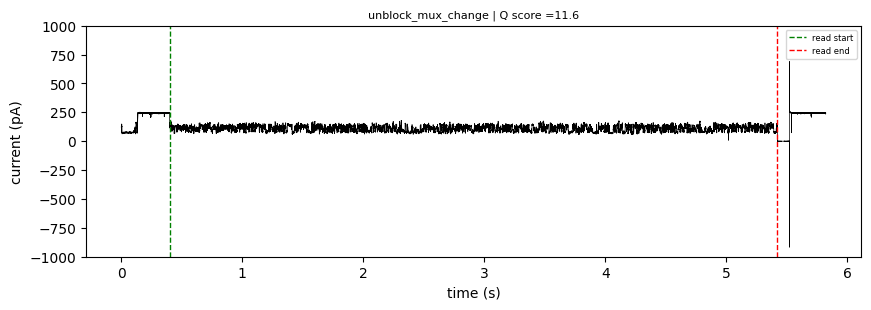

read_id: 00858dfa-738b-4e12-8a21-ea895cba3a20 | qs: 12.157029151916504 | start: 431339473 | end: 431374676 | duration_s: 7.04 | end_reason: unblock_mux_change


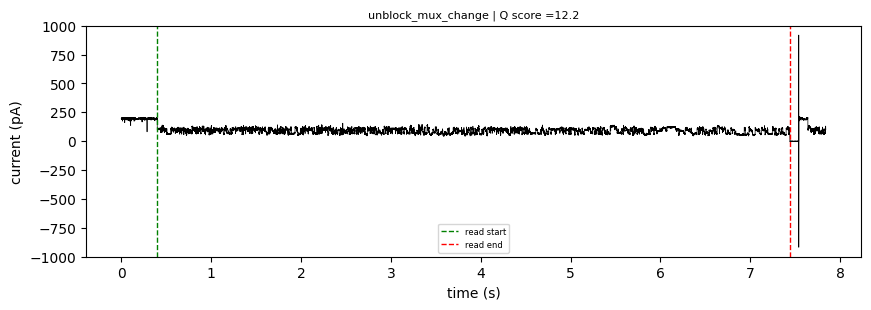

In [14]:
# Choose one end-reason category
TARGET_END_REASON = "unblock_mux_change"   # change this
N_TARGET = 40

# Options:
# "signal_positive"
# "signal_negative"
# "unblock_mux_change"
# "mux_change"

if TARGET_END_REASON not in pool:
    print("Available end reasons:", list(pool.keys()))
    raise ValueError(f"{TARGET_END_REASON} not found in pool")

c = pool[TARGET_END_REASON]

# Sort chronologically by read start position
c = sorted(c, key=lambda x: x["start"])

# Pick 40 evenly spaced reads across time
if len(c) <= N_TARGET:
    pick = c
else:
    pick = [c[int(i * (len(c) - 1) / (N_TARGET - 1))] for i in range(N_TARGET)]

print(TARGET_END_REASON, "available:", len(c), "picked:", len(pick))

for p in pick:
    print(
        "read_id:", p["read_id"],
        "| qs:", p.get("bam_qscore"),
        "| start:", p["start"],
        "| end:", p["end"],
        "| duration_s:", round(p["duration_s"], 2),
        "| end_reason:", p["end_reason"],
    )

    ch = resolve_raw_channel(h, p["channel"])

    a = max(0, p["start"] - PRE)
    b = min(h["Raw"][ch]["Signal"].shape[0], p["end"] + POST)

    sig = scale(ch, h["Raw"][ch]["Signal"][a:b])
    t = np.arange(len(sig)) / FS

    fig, ax = plt.subplots(figsize=(10, 3.0))

    ax.plot(t, sig, lw=0.5, color="black")

    ax.axvline(
        (p["start"] - a) / FS,
        color="green",
        ls="--",
        lw=1,
        label="read start",
    )

    ax.axvline(
        (p["end"] - a) / FS,
        color="red",
        ls="--",
        lw=1,
        label="read end",
    )

    if TARGET_END_REASON == "unblock_mux_change":
        ax.set_ylim(-1000, 1000)
    else:
        loy, hiy = np.percentile(sig, [0.1, 99.9])
        pad = 0.08 * (hiy - loy + 1e-6)
        ax.set_ylim(loy - pad, hiy + pad)

    ax.set_title(
        f"{TARGET_END_REASON} | Q score ={p.get('bam_qscore'):.1f}",
        fontsize=8,
    )

    ax.set_xlabel("time (s)")
    ax.set_ylabel("current (pA)")
    ax.legend(fontsize=6)

    plt.show()

## 2. Filter (length window + conducting), select 10/class, plot

In [5]:
h = h5py.File(F5, "r")  # read-only

# Find a channel with Reads table
example_reads = None
for ch in h["IntermediateData"]:
    if "Reads" in h["IntermediateData"][ch]:
        example_reads = h["IntermediateData"][ch]["Reads"]
        break

if example_reads is None:
    raise ValueError("No IntermediateData/<channel>/Reads dataset found.")

enum = h5py.check_enum_dtype(
    example_reads.dtype.fields["end_reason"][0]
)

inv = {v: k for k, v in enum.items()}

pool = collections.defaultdict(list)

for ch in h["IntermediateData"]:
    g = h["IntermediateData"][ch]

    if "Reads" not in g:
        continue

    r = g["Reads"][:]

    rid = r["read_id"]
    er = r["end_reason"]
    rs = r["read_start"]
    rl = r["read_length"]

    n = len(rid)
    i = 0

    while i < n:
        j = i

        # Group consecutive rows with the same read_id
        while j + 1 < n and rid[j + 1] == rid[i]:
            j += 1

        read_id = rid[i].decode() if isinstance(rid[i], bytes) else str(rid[i])
        end_reason = inv.get(int(er[j]))

        if read_id in high_q_read_ids:
            if END_REASONS is None or end_reason in END_REASONS:
                start = int(rs[i])
                end = int(rs[j] + rl[j])

                pool[end_reason].append(
                    {
                        "channel": ch,
                        "read_id": read_id,
                        "start": start,
                        "end": end,
                        "length": end - start,
                        "duration_s": (end - start) / FS,
                        "n_rows": j - i + 1,
                        "bam_qscore": q_by_read.get(read_id),
                        "end_reason": end_reason,
                    }
                )

        i = j + 1

print({k: len(v) for k, v in pool.items()})

{'signal_positive': 350591, 'unblock_mux_change': 8415, 'mux_change': 251, 'signal_negative': 743}


mux_change available: 251 picked: 10
read_id: 1edf5a80-51f9-4d8e-a96c-4702c73c1648 | qs: 18.92503547668457 | start: 28180275 | end: 28183156 | end_reason: mux_change


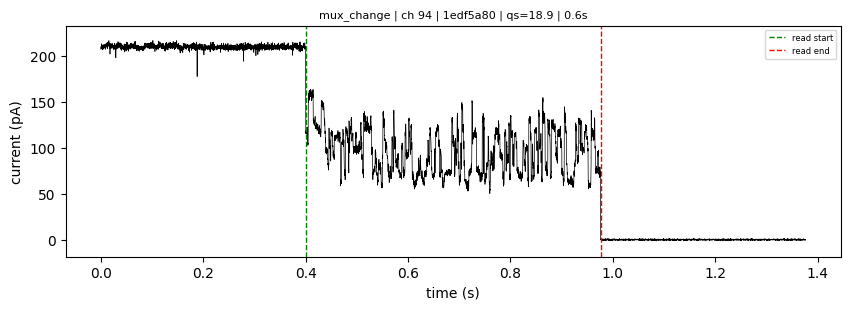

read_id: 226701f9-afab-46a9-9235-6200cc3b9642 | qs: 20.283910751342773 | start: 56208288 | end: 56209918 | end_reason: mux_change


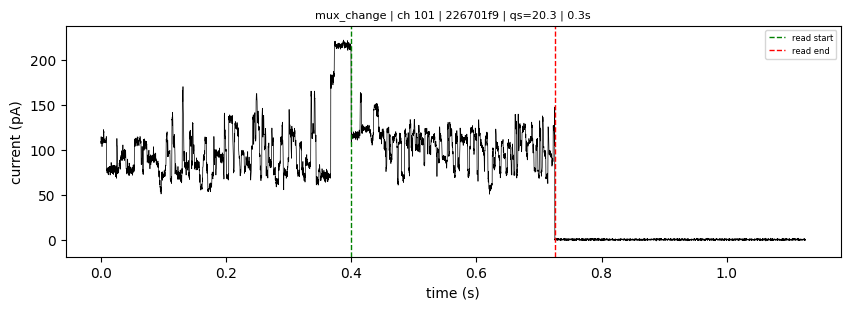

read_id: d06a0d20-8d8e-4c61-913e-a02c725c44bb | qs: 17.995275497436523 | start: 84265510 | end: 84267853 | end_reason: mux_change


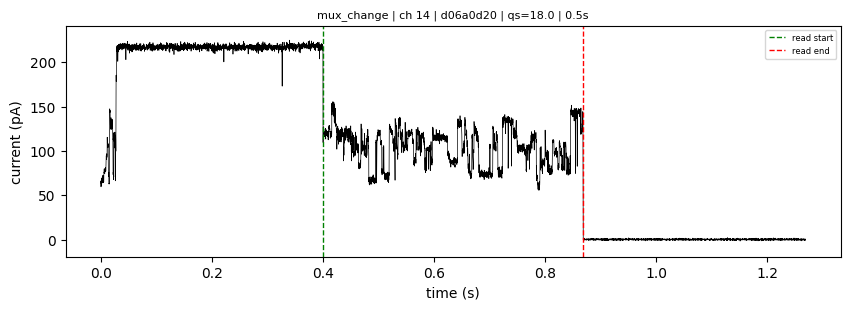

read_id: 61fa4e95-3d0e-4ca9-b406-dcde24b2adb3 | qs: 15.493240356445312 | start: 112312982 | end: 112314758 | end_reason: mux_change


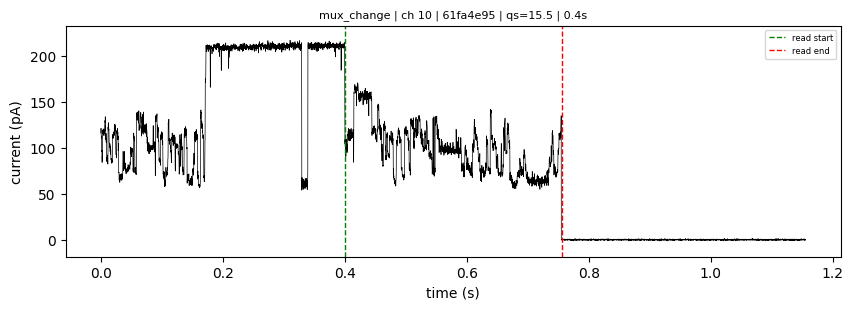

read_id: ae02ed6e-0aba-4000-98cf-b8a6bfc0b696 | qs: 22.346908569335938 | start: 168563980 | end: 168565603 | end_reason: mux_change


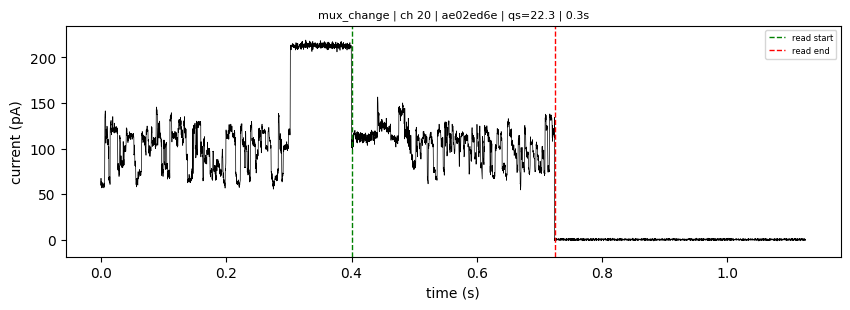

read_id: 3c4c76da-6285-4ece-a259-3d520bd3e507 | qs: 23.345115661621094 | start: 196603352 | end: 196605860 | end_reason: mux_change


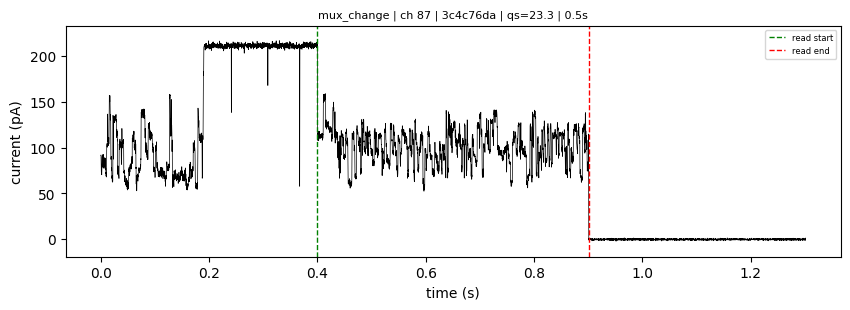

read_id: bd1978d3-ccbf-466d-bb31-c19d440e0e12 | qs: 13.42327880859375 | start: 252730756 | end: 252733633 | end_reason: mux_change


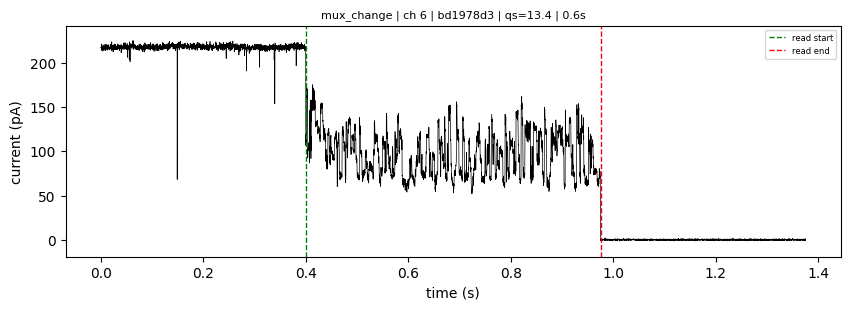

read_id: 095717e2-0860-4711-b2af-30745d39f91d | qs: 15.561187744140625 | start: 280829865 | end: 280831931 | end_reason: mux_change


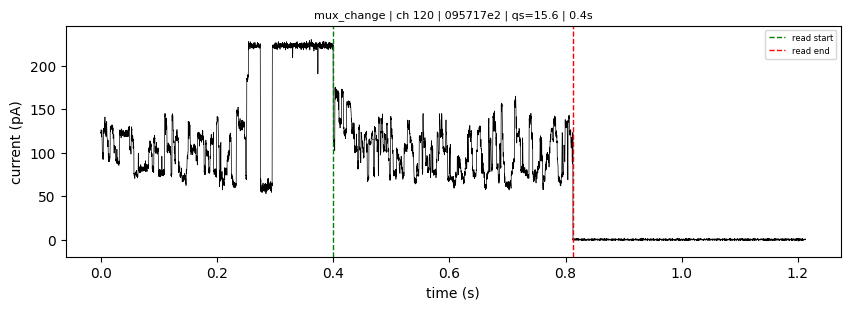

read_id: 7b966f6b-6e63-4c17-a3d6-ab00682b6d9a | qs: 18.255014419555664 | start: 336979546 | end: 336982254 | end_reason: mux_change


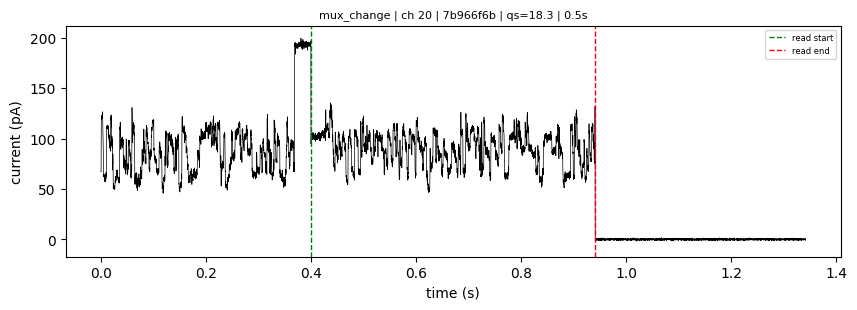

read_id: 8ac81608-b457-45bc-b002-65f21d25a895 | qs: 15.931617736816406 | start: 431934582 | end: 431990272 | end_reason: mux_change


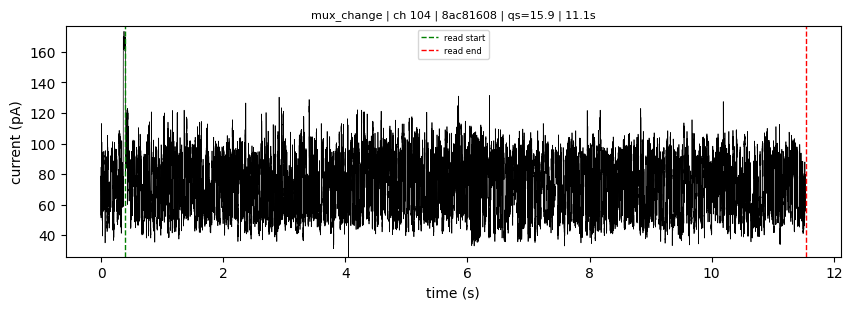

signal_negative available: 743 picked: 10
read_id: 8aac14e5-696e-4942-beb1-5005cae130ad | qs: 17.14551544189453 | start: 4375678 | end: 4427585 | end_reason: signal_negative


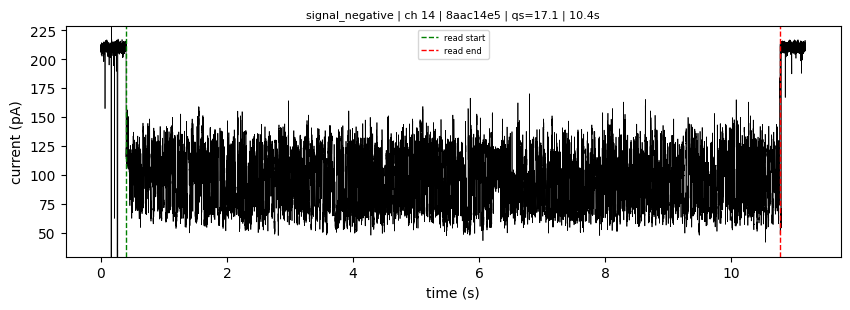

read_id: 246fccbb-6ebf-4744-926c-f26718a7b156 | qs: 12.188074111938477 | start: 153861158 | end: 153945608 | end_reason: signal_negative


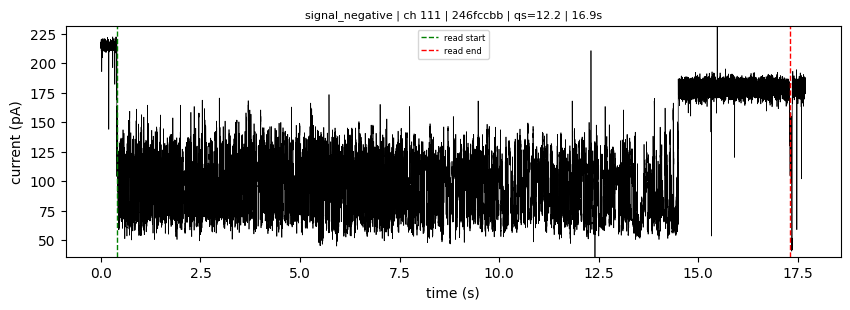

read_id: 2b616c62-c0ea-4aab-a2fb-9341780b2c2a | qs: 15.273313522338867 | start: 283087420 | end: 283093826 | end_reason: signal_negative


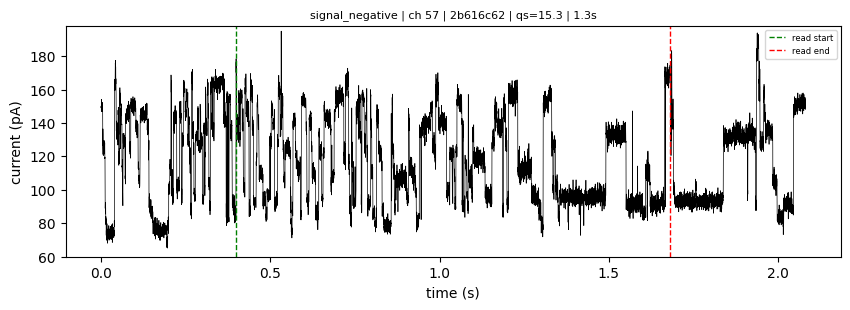

read_id: 3907f8bd-9cb5-4d6e-8add-e8a183359ed3 | qs: 10.855836868286133 | start: 330883260 | end: 330967842 | end_reason: signal_negative


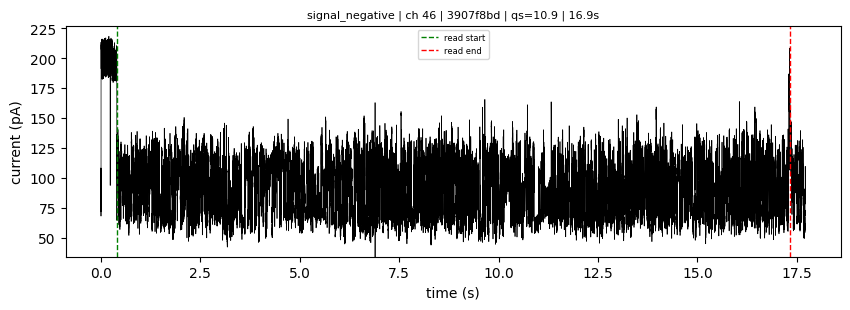

read_id: f00b0e2e-a640-44a2-9ab9-907c8c9e6feb | qs: 13.09083080291748 | start: 368982980 | end: 369044832 | end_reason: signal_negative


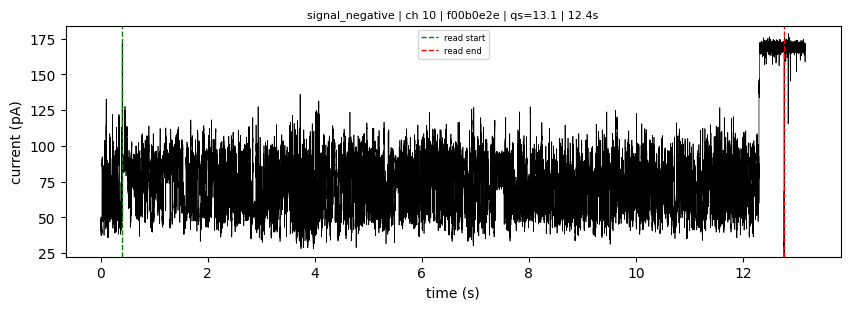

read_id: 3fb6c68d-5e2e-4bd1-bcab-00082a46aaba | qs: 12.793540954589844 | start: 379169907 | end: 379238666 | end_reason: signal_negative


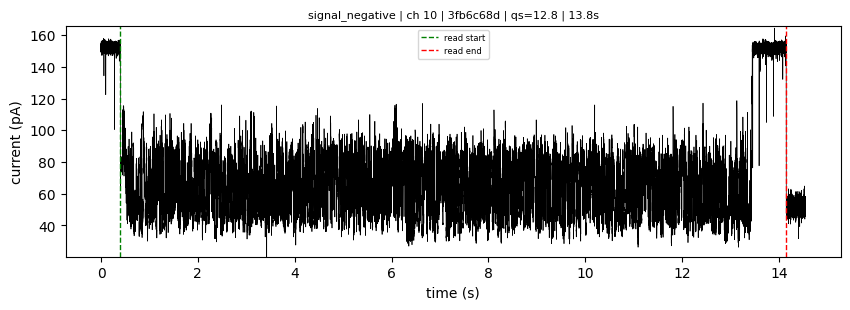

read_id: 2a1d8ede-78b3-40c4-97e2-b44a705165f6 | qs: 10.929231643676758 | start: 384989379 | end: 385080866 | end_reason: signal_negative


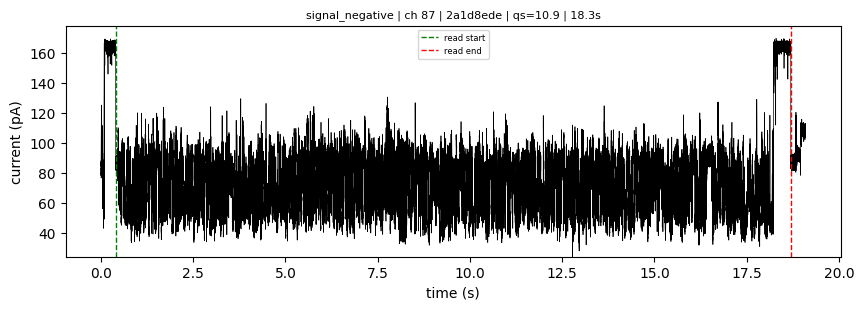

read_id: d2ec1d8e-f256-47d1-9064-158d0d8ebade | qs: 15.795347213745117 | start: 391183351 | end: 391264780 | end_reason: signal_negative


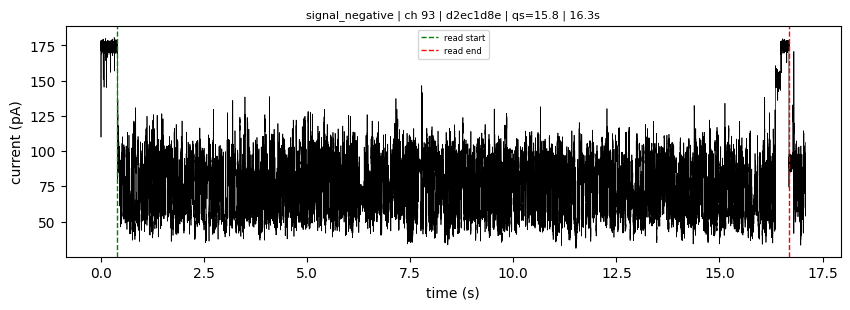

read_id: de18e356-bc98-46c4-857e-1c0bc7ff200c | qs: 16.43907928466797 | start: 401453689 | end: 401513747 | end_reason: signal_negative


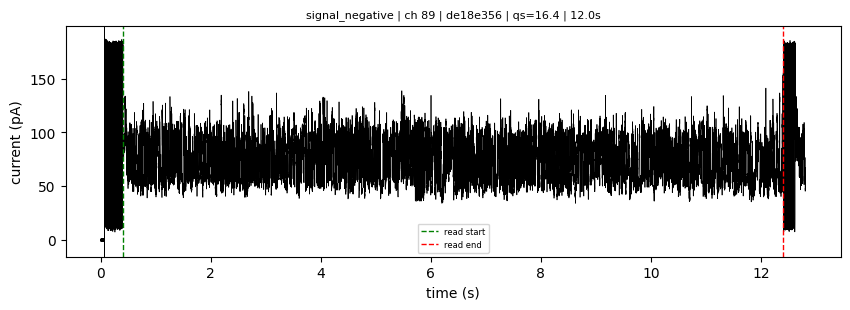

read_id: 66ee84c7-4f30-4871-8808-8aa76c9b8f72 | qs: 11.453447341918945 | start: 431453484 | end: 431511491 | end_reason: signal_negative


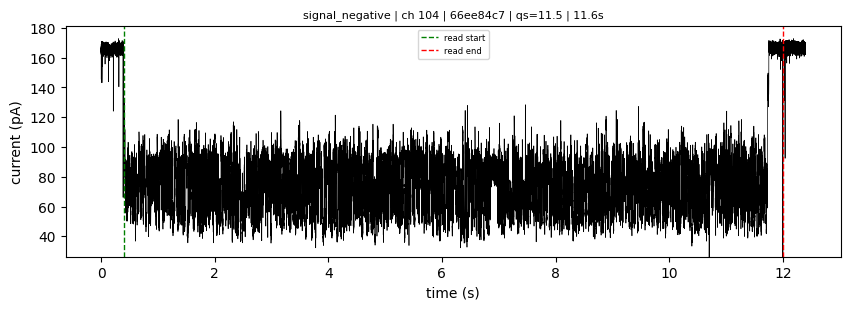

signal_positive available: 350591 picked: 10
read_id: 84b0cc80-de46-4834-92be-7c2cdd617939 | qs: 19.388525009155273 | start: 875357 | end: 877100 | end_reason: signal_positive


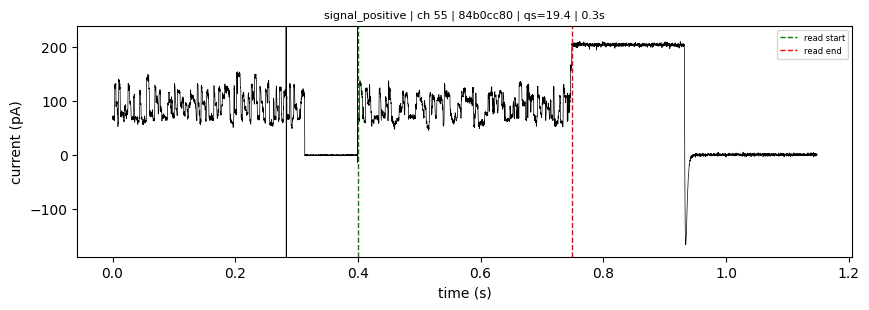

read_id: 31ec57c1-1a1b-4eb6-a0a2-eeab745e2e48 | qs: 20.92283058166504 | start: 35255079 | end: 35316100 | end_reason: signal_positive


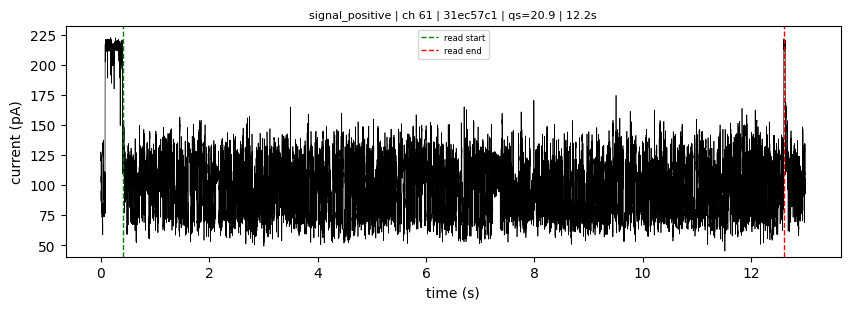

read_id: cc19c376-327d-4c10-8fcf-f39f13162e69 | qs: 17.33014488220215 | start: 69774501 | end: 69825113 | end_reason: signal_positive


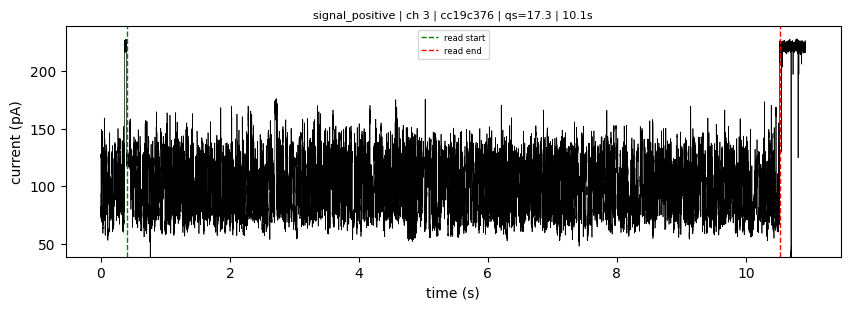

read_id: bc6d2cb4-4dd8-4312-b99f-6d2aa2e85118 | qs: 18.835729598999023 | start: 106022400 | end: 106076183 | end_reason: signal_positive


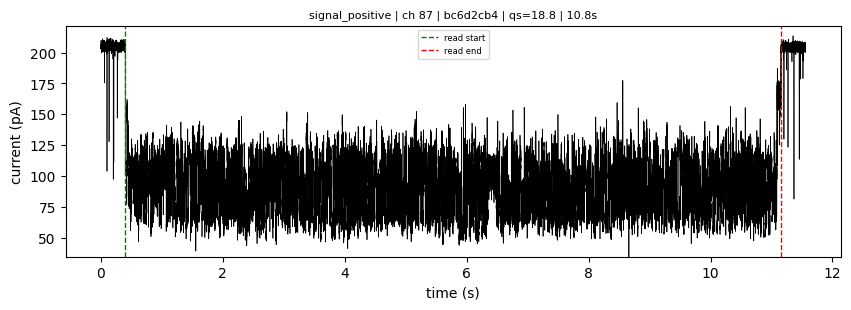

read_id: 6d9a3ba3-6ac4-404d-ab93-2a3e2869bc93 | qs: 15.07015323638916 | start: 144825916 | end: 144883187 | end_reason: signal_positive


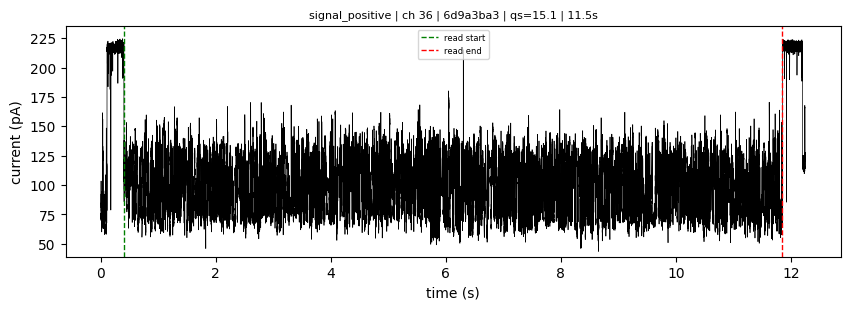

read_id: 2d539763-0b15-4b9e-8275-22e6ad54557d | qs: 15.515129089355469 | start: 185687004 | end: 185749514 | end_reason: signal_positive


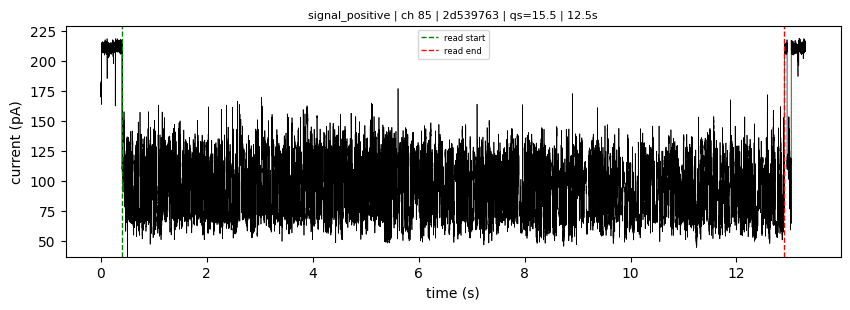

read_id: 3fac7236-b3de-4a0d-82c2-6f4fe128ab49 | qs: 17.516719818115234 | start: 231069129 | end: 231117416 | end_reason: signal_positive


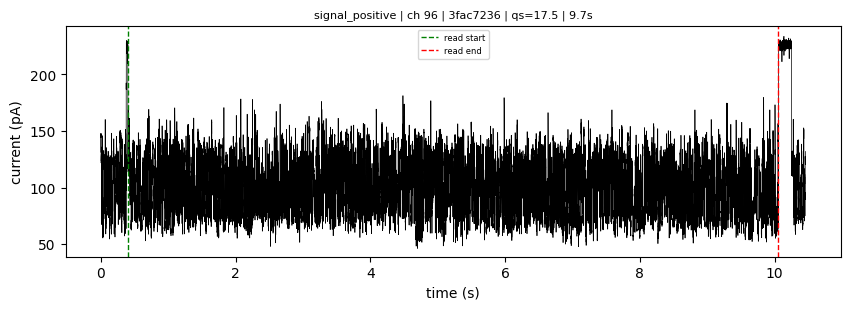

read_id: f1df9f44-ec1d-4360-94b8-2ff343fb190c | qs: 18.485082626342773 | start: 278942131 | end: 278995637 | end_reason: signal_positive


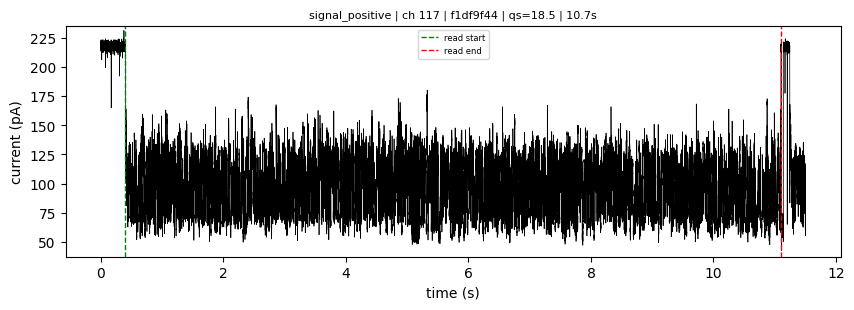

read_id: 4da19779-ee8b-4d0f-aca2-0670ed7d05b2 | qs: 19.645246505737305 | start: 330741783 | end: 330799887 | end_reason: signal_positive


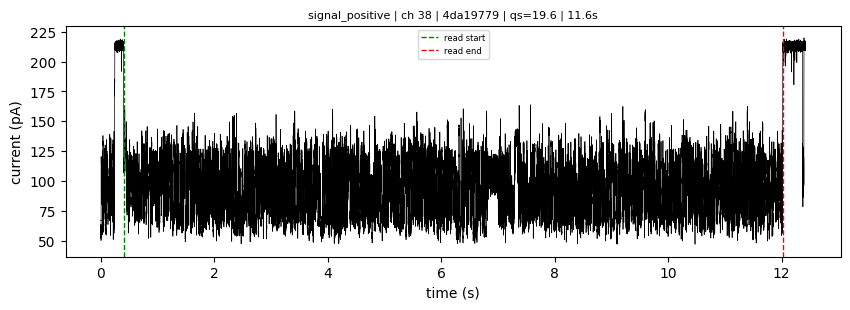

read_id: c3a2472f-e084-4a0c-beb2-6a20105a2db7 | qs: 19.224674224853516 | start: 431915090 | end: 431988817 | end_reason: signal_positive


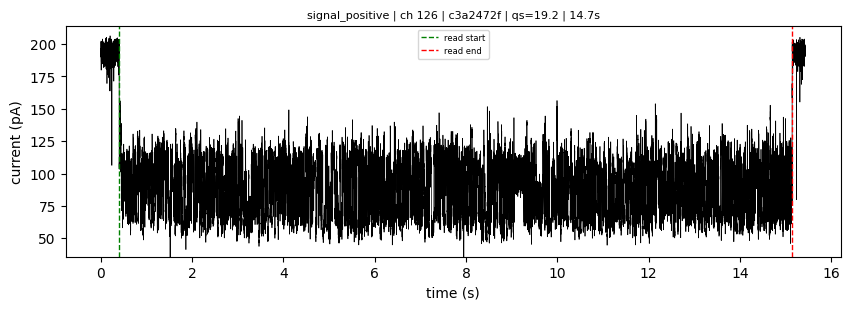

unblock_mux_change available: 8415 picked: 10
read_id: b83b7dfa-94f0-422e-b175-da5ca87c8e86 | qs: 23.134443283081055 | start: 1188413 | end: 1215347 | end_reason: unblock_mux_change


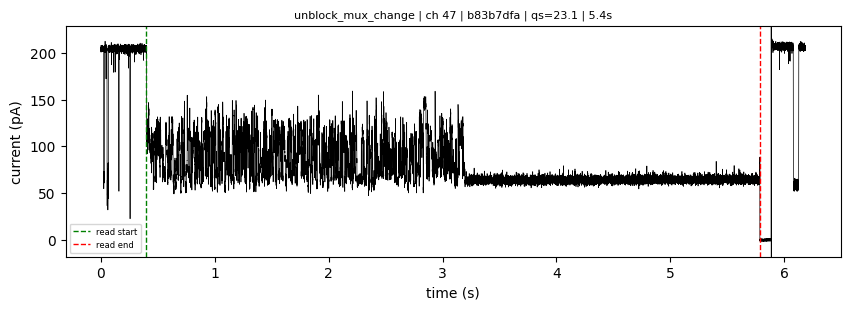

read_id: 42d1faec-96cb-4998-8191-16601f4d85b9 | qs: 17.337310791015625 | start: 44031470 | end: 44060188 | end_reason: unblock_mux_change


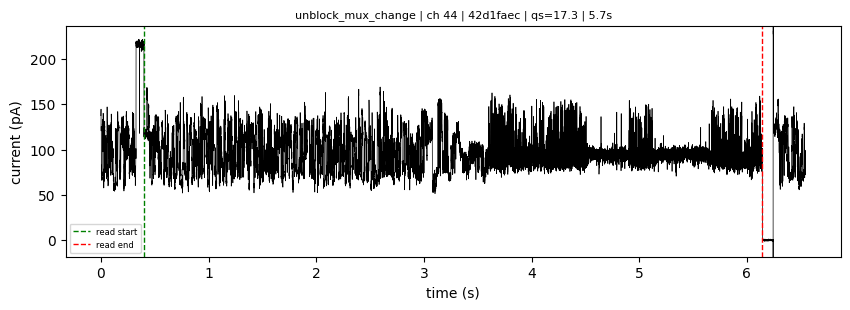

read_id: 948dfbed-30de-4eb5-8629-35fcb9ac93da | qs: 14.506617546081543 | start: 81936963 | end: 81966428 | end_reason: unblock_mux_change


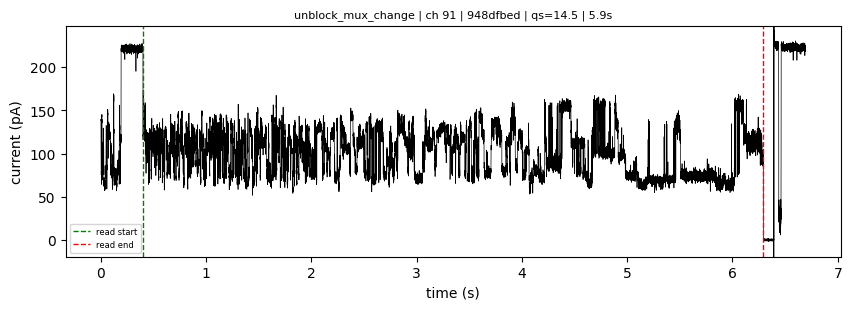

read_id: a4c352a2-bd2b-4559-b4df-957935e33756 | qs: 19.743637084960938 | start: 117609787 | end: 117656525 | end_reason: unblock_mux_change


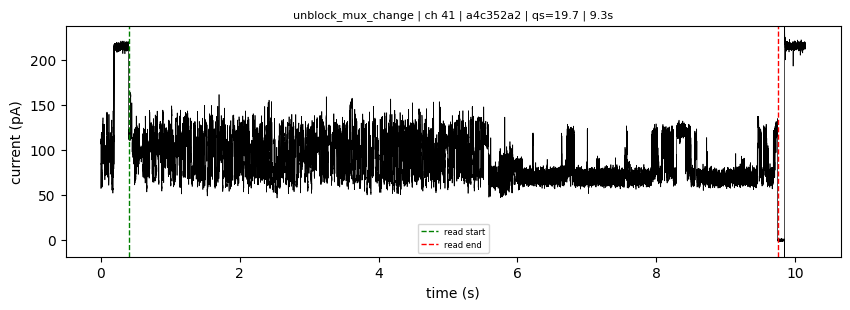

read_id: c8efd974-cd3b-496e-a6d8-f63fd1aeb195 | qs: 15.52613353729248 | start: 154962101 | end: 155063893 | end_reason: unblock_mux_change


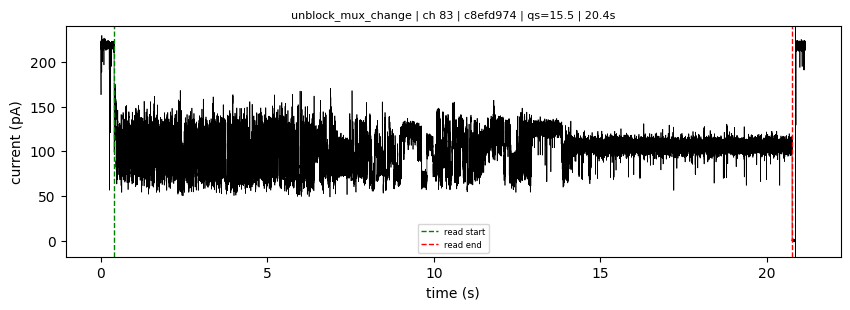

read_id: 8e46f15f-f179-4188-a19e-3b64c4a41de6 | qs: 10.794523239135742 | start: 200483173 | end: 200585820 | end_reason: unblock_mux_change


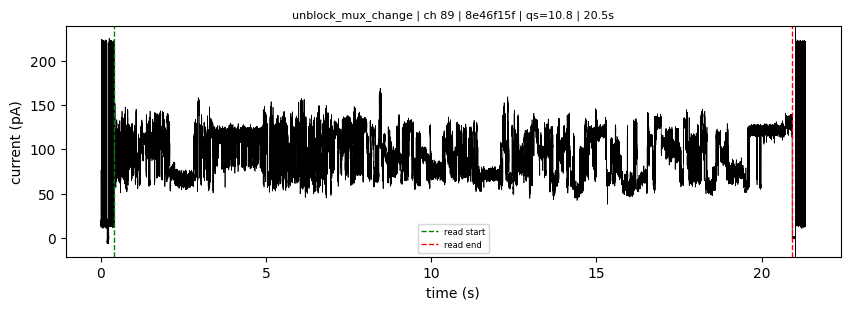

read_id: eb860f05-27aa-4b95-94ae-d8b8a7e63436 | qs: 17.52298927307129 | start: 244431983 | end: 244480786 | end_reason: unblock_mux_change


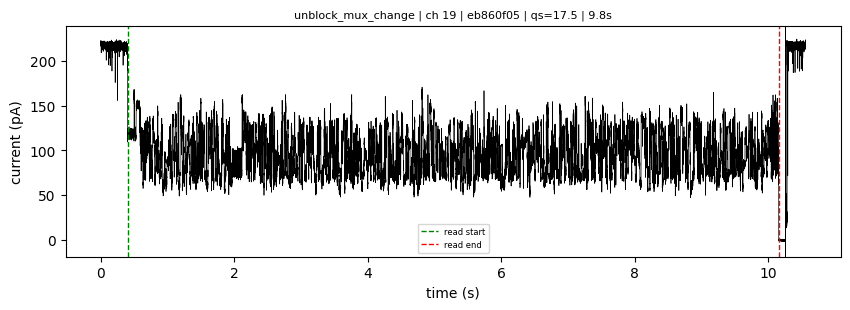

read_id: a7500c80-435c-4899-9eb8-b1df67beb4a0 | qs: 14.382801055908203 | start: 289699962 | end: 289738880 | end_reason: unblock_mux_change


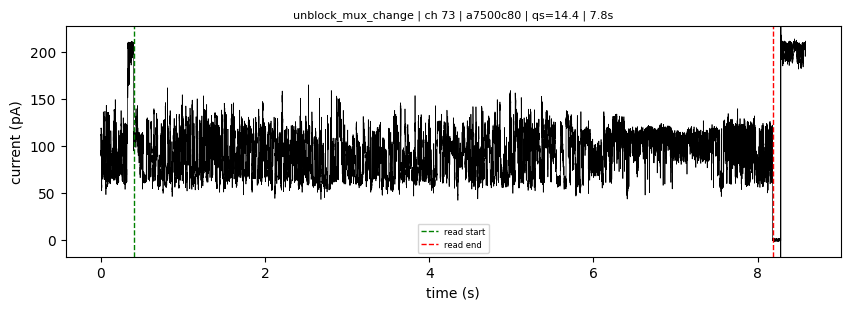

read_id: e0a11eec-8471-4049-8097-59ea1c49b7e9 | qs: 13.941617012023926 | start: 345172441 | end: 345193737 | end_reason: unblock_mux_change


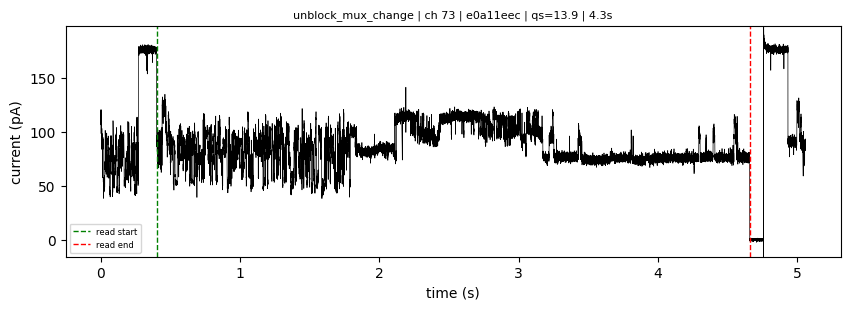

read_id: 00858dfa-738b-4e12-8a21-ea895cba3a20 | qs: 12.157029151916504 | start: 431339473 | end: 431374676 | end_reason: unblock_mux_change


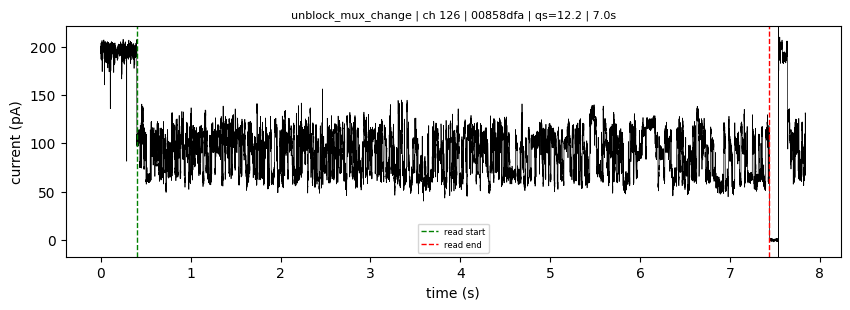

In [6]:
def resolve_raw_channel(h, ch):
    if ch in h["Raw"]:
        return ch

    ch_str = str(ch)
    if ch_str in h["Raw"]:
        return ch_str

    ch_prefixed = f"Channel_{ch_str}"
    if ch_prefixed in h["Raw"]:
        return ch_prefixed

    raise KeyError(f"Could not find raw signal channel for {ch}")


def scale(ch, raw):
    attrs = h["Raw"][ch]["Meta"].attrs
    return (raw.astype(np.float32) + attrs["offset"]) * attrs["range"] / attrs["digitisation"]


for cls in sorted(pool.keys()):
    c = pool[cls]

    # Chronological order by start position
    c.sort(key=lambda x: x["start"])

    if len(c) == 0:
        print(cls, "has no reads after Q-score filtering")
        continue

    if len(c) <= N:
        pick = c
    else:
        pick = [c[int(i * (len(c) - 1) / (N - 1))] for i in range(N)]

    print(cls, "available:", len(c), "picked:", len(pick))

    for p in pick:
        print(
            "read_id:", p["read_id"],
            "| qs:", p["bam_qscore"],
            "| start:", p["start"],
            "| end:", p["end"],
            "| end_reason:", p["end_reason"],
        )

        ch = resolve_raw_channel(h, p["channel"])

        a = max(0, p["start"] - PRE)
        b = min(h["Raw"][ch]["Signal"].shape[0], p["end"] + POST)

        sig = scale(ch, h["Raw"][ch]["Signal"][a:b])
        t = np.arange(len(sig)) / FS

        fig, ax = plt.subplots(figsize=(10, 3.0))

        ax.plot(t, sig, lw=0.5, color="black")

        ax.axvline((p["start"] - a) / FS, color="green", ls="--", lw=1, label="read start")
        ax.axvline((p["end"] - a) / FS, color="red", ls="--", lw=1, label="read end")

        if p["end_reason"] == "unblock_mux_change":
            ax.set_ylim(-1000, 1000)
        else:
            loy, hiy = np.percentile(sig, [0.1, 99.9])
            pad = 0.08 * (hiy - loy + 1e-6)
            ax.set_ylim(loy - pad, hiy + pad)

        ax.set_title(
            f"{cls} | Q score={p['bam_qscore']:.1f}",
            fontsize=8,
        )

        ax.set_xlabel("time (s)")
        ax.set_ylabel("current (pA)")
        ax.legend(fontsize=6)

        plt.show()

Saving: 3c4c76da-6285-4ece-a259-3d520bd3e507 | end_reason: mux_change | qs: 23.345115661621094 | start: 196603352 | end: 196605860


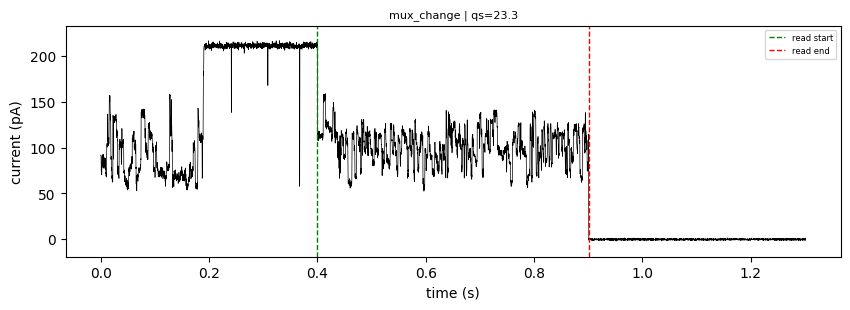

Done. Saved files to: /nfs/turbo/umms-atheylab/kdiya/1_sandbox_end_reason/6_1_26_Figure_2/selected_signal_plots


In [16]:
from pathlib import Path

# Put the full read IDs you like here
SELECTED_READ_IDS = [
    "3c4c76da-6285-4ece-a259-3d520bd3e507"
]

OUT_DIR = Path("selected_signal_plots")
OUT_DIR.mkdir(exist_ok=True)

# Flatten pool into a read_id -> metadata dictionary
read_lookup = {}

for end_reason, reads in pool.items():
    for p in reads:
        read_lookup[p["read_id"]] = p

for read_id in SELECTED_READ_IDS:
    if read_id not in read_lookup:
        print("Not found in pool:", read_id)
        continue

    p = read_lookup[read_id]

    print(
        "Saving:",
        p["read_id"],
        "| end_reason:", p["end_reason"],
        "| qs:", p.get("bam_qscore"),
        "| start:", p["start"],
        "| end:", p["end"],
    )

    ch = resolve_raw_channel(h, p["channel"])

    a = max(0, p["start"] - PRE)
    b = min(h["Raw"][ch]["Signal"].shape[0], p["end"] + POST)

    sig = scale(ch, h["Raw"][ch]["Signal"][a:b])
    t = np.arange(len(sig)) / FS

    fig, ax = plt.subplots(figsize=(10, 3.0))

    ax.plot(t, sig, lw=0.5, color="black")

    ax.axvline(
        (p["start"] - a) / FS,
        color="green",
        ls="--",
        lw=1,
        label="read start",
    )

    ax.axvline(
        (p["end"] - a) / FS,
        color="red",
        ls="--",
        lw=1,
        label="read end",
    )

    # Fixed y-axis only for unblock_mux_change
    if p["end_reason"] == "unblock_mux_change":
        ax.set_ylim(-1000, 1000)
    else:
        loy, hiy = np.percentile(sig, [0.1, 99.9])
        pad = 0.08 * (hiy - loy + 1e-6)
        ax.set_ylim(loy - pad, hiy + pad)

    ax.set_title(
        f"{p['end_reason']} | qs={p.get('bam_qscore'):.1f}",
        fontsize=8,
    )

    ax.set_xlabel("time (s)")
    ax.set_ylabel("current (pA)")
    ax.legend(fontsize=6)

    # Make filename safe and short
    safe_read_id = read_id.replace("/", "_").replace("\\", "_")
    base = OUT_DIR / f"{p['end_reason']}_{safe_read_id}"

    fig.savefig(f"{base}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{base}.svg", bbox_inches="tight")

    plt.show()
    plt.close(fig)

print("Done. Saved files to:", OUT_DIR.resolve())

In [7]:
def clean_end_reason_for_compare(x):
    s = str(x).lower()
    s = s.replace("endreasonenum.", "")
    s = s.replace("endreason.", "")
    return s


def parse_pod5_metrics(pod5_path, target_read_ids=None):
    pod5_path = Path(pod5_path)

    if pod5_path.is_dir():
        pod5_files = sorted(pod5_path.glob("*.pod5"))
    else:
        pod5_files = [pod5_path]

    rows = []

    for pod5_file in pod5_files:
        with p5.Reader(str(pod5_file)) as reader:
            for read in reader.reads():
                read_id = str(read.read_id)

                if target_read_ids is not None and read_id not in target_read_ids:
                    continue

                start = int(read.start_sample)

                if hasattr(read, "sample_count"):
                    length = int(read.sample_count)
                else:
                    length = int(read.num_samples)

                rows.append(
                    {
                        "read_id": read_id,
                        "pod5_file": str(pod5_file),
                        "pod5_start": start,
                        "pod5_end": start + length,
                        "pod5_length": length,
                        "pod5_end_reason": clean_end_reason_for_compare(read.end_reason),
                    }
                )

    return pd.DataFrame(rows)


bulk_rows = []

for end_reason, reads in pool.items():
    for p in reads:
        bulk_rows.append(
            {
                "read_id": p["read_id"],
                "bulk_start": p["start"],
                "bulk_end": p["end"],
                "bulk_length": p["length"],
                "bulk_end_reason": clean_end_reason_for_compare(p["end_reason"]),
                "bam_qscore": p["bam_qscore"],
            }
        )

bulk_df = pd.DataFrame(bulk_rows)

pod5_df = parse_pod5_metrics(
    POD5_PATH,
    target_read_ids=set(bulk_df["read_id"]),
)

verify_df = bulk_df.merge(
    pod5_df,
    on="read_id",
    how="left",
)

verify_df["start_match"] = verify_df["bulk_start"] == verify_df["pod5_start"]
verify_df["end_match"] = verify_df["bulk_end"] == verify_df["pod5_end"]
verify_df["length_match"] = verify_df["bulk_length"] == verify_df["pod5_length"]
verify_df["end_reason_match"] = verify_df["bulk_end_reason"] == verify_df["pod5_end_reason"]

verify_df["all_match"] = (
    verify_df["start_match"]
    & verify_df["end_match"]
    & verify_df["length_match"]
    & verify_df["end_reason_match"]
)

print("Bulk reads checked:", len(bulk_df))
print("POD5 reads found:", len(pod5_df))
print("All-match count:", int(verify_df["all_match"].sum()))

display(
    verify_df[
        [
            "read_id",
            "bam_qscore",
            "bulk_start",
            "pod5_start",
            "start_match",
            "bulk_end",
            "pod5_end",
            "end_match",
            "bulk_length",
            "pod5_length",
            "length_match",
            "bulk_end_reason",
            "pod5_end_reason",
            "end_reason_match",
            "all_match",
        ]
    ].head(50)
)

mismatches = verify_df[
    (verify_df["all_match"] != True)
    | verify_df["pod5_start"].isna()
]

print("Mismatches or missing POD5 reads:", len(mismatches))

display(mismatches.head(50))

Bulk reads checked: 360000
POD5 reads found: 360000
All-match count: 0


,read_id,bam_qscore,bulk_start,pod5_start,start_match,bulk_end,pod5_end,end_match,bulk_length,pod5_length,length_match,bulk_end_reason,pod5_end_reason,end_reason_match,all_match
0,84b0cc80-de46-4834-92be-7c2cdd617939,19.388525,875357,875357,True,877100,877100,True,1743,1743,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
1,e9a8d4ab-ace2-4a9e-a3f4-f481eb9b3ce6,24.595753,875357,875357,True,877026,877026,True,1669,1669,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
2,38c19f87-f9fa-489b-8f78-5f289ef2e1e5,23.045033,1175496,1175496,True,1229661,1229661,True,54165,54165,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
3,b1cd1778-aae4-4450-8220-5a680af818a3,22.263983,1176306,1176306,True,1248373,1248373,True,72067,72067,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
4,d49ef070-52eb-416a-b32d-16400d01aff6,14.730210,1176358,1176358,True,1251516,1251516,True,75158,75158,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
5,c89f9c1c-a522-45fe-bc48-a39565538885,18.662849,1176437,1176437,True,1233000,1233000,True,56563,56563,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
6,126ae81d-420c-4166-98f0-88c8c032b692,19.881853,1176446,1176446,True,1232305,1232305,True,55859,55859,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
7,0f70a29e-c147-4a23-b610-9cd89e955859,12.406742,1176494,1176494,True,1226186,1226186,True,49692,49692,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
8,9b66b774-f2b7-4ea0-8b2f-1e0d2a4a6cfc,20.324661,1177269,1177269,True,1234126,1234126,True,56857,56857,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False
9,dd0f2e0e-997b-4cd0-92f0-da5d4af0f4e4,20.109241,1177494,1177494,True,1232719,1232719,True,55225,55225,True,signal_positive,"endreason(reason=<signal_positive: 4>, forced=...",False,False


Mismatches or missing POD5 reads: 360000


,read_id,bulk_start,bulk_end,bulk_length,bulk_end_reason,bam_qscore,pod5_file,pod5_start,pod5_end,pod5_length,pod5_end_reason,start_match,end_match,length_match,end_reason_match,all_match
0,84b0cc80-de46-4834-92be-7c2cdd617939,875357,877100,1743,signal_positive,19.388525,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,875357,877100,1743,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
1,e9a8d4ab-ace2-4a9e-a3f4-f481eb9b3ce6,875357,877026,1669,signal_positive,24.595753,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,875357,877026,1669,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
2,38c19f87-f9fa-489b-8f78-5f289ef2e1e5,1175496,1229661,54165,signal_positive,23.045033,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1175496,1229661,54165,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
3,b1cd1778-aae4-4450-8220-5a680af818a3,1176306,1248373,72067,signal_positive,22.263983,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1176306,1248373,72067,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
4,d49ef070-52eb-416a-b32d-16400d01aff6,1176358,1251516,75158,signal_positive,14.730210,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1176358,1251516,75158,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
5,c89f9c1c-a522-45fe-bc48-a39565538885,1176437,1233000,56563,signal_positive,18.662849,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1176437,1233000,56563,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
6,126ae81d-420c-4166-98f0-88c8c032b692,1176446,1232305,55859,signal_positive,19.881853,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1176446,1232305,55859,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
7,0f70a29e-c147-4a23-b610-9cd89e955859,1176494,1226186,49692,signal_positive,12.406742,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1176494,1226186,49692,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
8,9b66b774-f2b7-4ea0-8b2f-1e0d2a4a6cfc,1177269,1234126,56857,signal_positive,20.324661,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1177269,1234126,56857,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
9,dd0f2e0e-997b-4cd0-92f0-da5d4af0f4e4,1177494,1232719,55225,signal_positive,20.109241,/nfs/turbo/umms-atheylab/gregfar/SMS/SMS_POP_d...,1177494,1232719,55225,"endreason(reason=<signal_positive: 4>, forced=...",True,True,True,False,False
